# San Francisco Rent Board Housing Inventory
## Cleaning Comparisons and Bivariate Analysis

## Step 1 — Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
# Keep tick marks visible on every rendered axis.
plt.rcParams.update({"xtick.bottom": True, "ytick.left": True, "xtick.major.size": 5, "ytick.major.size": 5, "xtick.major.width": 1, "ytick.major.width": 1})


## Step 2 — Load the dataset

In [5]:
# Load the rent-board dataset
# The notebook works in Colab, Jupyter, or the local workspace.
from pathlib import Path

candidate_paths = [
    Path("/content/Rent_Board_Housing_Inventory_20261006.csv"),
    Path("Rent_Board_Housing_Inventory_20261006.csv"),
    Path("data/Rent_Board_Housing_Inventory_20261006.csv"),
    Path("upload/Rent_Board_Housing_Inventory_20261005(1).csv"),
    Path("/workspace/scratch/1651c01287fe/upload/Rent_Board_Housing_Inventory_20261005(1).csv"),
]
csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    csv_files = sorted(Path(".").glob("*.csv"))
    if len(csv_files) == 1:
        csv_path = csv_files[0]
    else:
        raise FileNotFoundError(
            "Place Rent_Board_Housing_Inventory_20261006.csv beside this notebook "
            "or upload it to Colab before running this cell."
        )

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape}")


Loaded: upload/Rent_Board_Housing_Inventory_20261005(1).csv
Shape: (551551, 28)


## Step 3 — Inspect the original structure

In [7]:
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551551 entries, 0 to 551550
Data columns (total 28 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   unique_id                            551551 non-null  float64
 1   block_num                            551549 non-null  object 
 2   unit_count                           551549 non-null  float64
 3   case_type_name                       551551 non-null  object 
 4   submission_year                      551551 non-null  int64  
 5   block_address                        551473 non-null  object 
 6   occupancy_type                       551551 non-null  object 
 7   occupancy_or_vacancy_date            448316 non-null  object 
 8   occupancy_or_vacancy_date_year       481775 non-null  object 
 9   bedroom_count                        521007 non-null  object 
 10  bathroom_count                       521101 non-null  object 
 11  square_footag

      unique_id block_num  unit_count                               case_type_name  submission_year              block_address         occupancy_type occupancy_or_vacancy_date occupancy_or_vacancy_date_year bedroom_count bathroom_count   square_footage monthly_rent base_rent_includes_water_sewer base_rent_includes_natural_gas base_rent_includes_electricity base_rent_includes_refuse_recycling base_rent_includes_other_utilities past_occupancy vacancy_date signature_date                                              occupancy_or_vacancy_date_history  year_property_built                                point       analysis_neighborhood  supervisor_district      data_as_of  data_loaded_at
0  7.136623e+18      0285        70.0  Housing Inventory - Unit information (2022)             2022   400 Block of STOCKTON ST  Occupied by non-owner                 12/1/2020                           2020        Studio   One bathroom    501-750 Sq.Ft  $1501-$1750                              Y             

## Step 4 — Create the cleaning copy

In [9]:
cleaned = df.copy(deep = True)
print('Cleaning copy created:', cleaned.shape)

Cleaning copy created: (551551, 28)


### Convert text columns to string and remove extra spaces

In [11]:
# Convert text columns to string and remove extra spaces
text_columns = [
    "block_num",
    "case_type_name",
    "block_address",
    "occupancy_type",
    "bedroom_count",
    "bathroom_count",
    "square_footage",
    "monthly_rent",
    "base_rent_includes_water_sewer",
    "base_rent_includes_natural_gas",
    "base_rent_includes_electricity",
    "base_rent_includes_refuse_recycling",
    "base_rent_includes_other_utilities",
    "past_occupancy",
    "point",
    "analysis_neighborhood",
    "supervisor_district"
]

# Using 'cleaned' as defined in cell SxAXMjdv8f-7 instead of 'cleaned'
for col in text_columns:
    if col in cleaned.columns:
        cleaned[col] = (
            cleaned[col]
            .astype("string")
            .str.strip()
        )
    elif f'"{col}"' in cleaned.columns:
        cleaned[f'"{col}"'] = (
            cleaned[f'"{col}"']
            .astype("string")
            .str.strip()
        )

## Step 8 — Convert numeric columns

In [13]:
# Convert known numeric columns only when they exist.
cleaned.columns = cleaned.columns.str.replace('"', '', regex=False).str.strip()
numeric_columns = ['unit_count', 'submission_year', 'year_property_built', 'supervisor_district']
for col in numeric_columns:
    if col in cleaned.columns:
        cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')
display(cleaned[[c for c in numeric_columns if c in cleaned.columns]].dtypes.to_frame('dtype'))


                       dtype
unit_count           float64
submission_year        int64
year_property_built  float64
supervisor_district  Float64

## Step 9 — Convert date columns

In [15]:
# Convert date fields and preserve a validation summary for the occupancy/vacancy date.
date_columns = [
    'occupancy_or_vacancy_date', 'vacancy_date', 'signature_date',
    'data_as_of', 'data_loaded_at'
]
for col in date_columns:
    if col in cleaned.columns:
        cleaned[col] = pd.to_datetime(cleaned[col], errors='coerce', format='mixed')

date_col = 'occupancy_or_vacancy_date'
if date_col in cleaned.columns:
    cleaned['occupancy_or_vacancy_date_year_from_date'] = cleaned[date_col].dt.year
    print(f"{date_col} dtype:", cleaned[date_col].dtype)
    print("Missing/invalid occupancy-vacancy dates:", int(cleaned[date_col].isna().sum()))
else:
    print(f"{date_col} is not available.")
print("Date columns converted:", [c for c in date_columns if c in cleaned.columns])


occupancy_or_vacancy_date dtype: datetime64[ns]
Missing/invalid occupancy-vacancy dates: 103391
Date columns converted: ['occupancy_or_vacancy_date', 'vacancy_date', 'signature_date', 'data_as_of', 'data_loaded_at']


In [16]:
# Missing-value summary at the beginning of cleaning

missing_table = (
    cleaned.isna()
    .sum()
    .reset_index()
)

missing_table.columns = [
    "column",
    "missing_count"
]

missing_table["missing_percentage"] = (
    missing_table["missing_count"]
    / len(cleaned)
    * 100
)

missing_table = missing_table.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_table)

                                      column  missing_count  missing_percentage
19                              vacancy_date         530409           96.166810
17        base_rent_includes_other_utilities         512939           92.999378
21         occupancy_or_vacancy_date_history         470466           85.298730
18                            past_occupancy         153244           27.784194
7                  occupancy_or_vacancy_date         103391           18.745501
28  occupancy_or_vacancy_date_year_from_date         103391           18.745501
8             occupancy_or_vacancy_date_year          69776           12.650870
12                              monthly_rent          66509           12.058540
9                              bedroom_count          30544            5.537838
10                            bathroom_count          30450            5.520795
22                       year_property_built          16002            2.901273
11                            square_foo

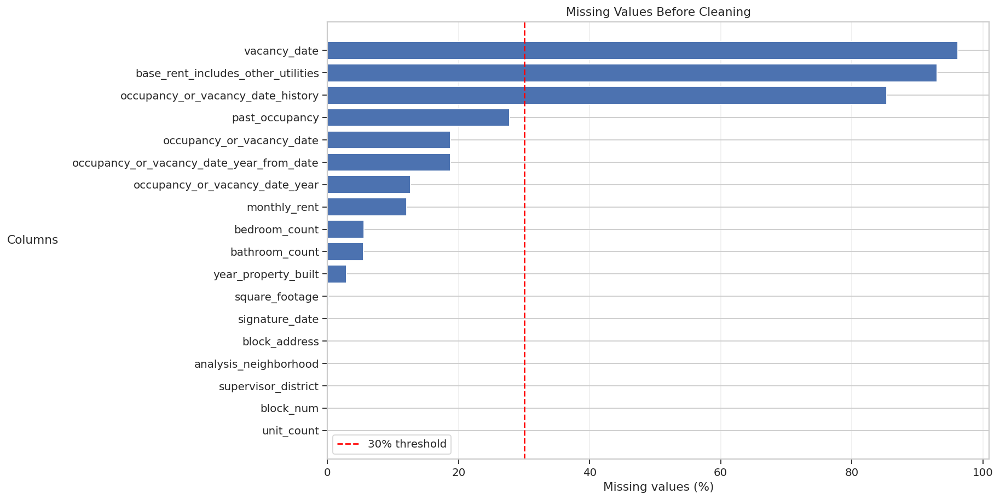

In [17]:
#Plot the graph to show missing pecentage and each column. These missing values were only identified by is_na
import matplotlib.pyplot as plt

plot_data = missing_table[
    missing_table["missing_count"] > 0
].head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_data["column"][::-1],
    plot_data["missing_percentage"][::-1]
)
plt.axvline(
    30,
    color="red",
    linestyle="--",
    label="30% threshold"
)

plt.xlabel("Missing values (%)")
plt.ylabel("Columns",rotation=0,labelpad=40,va="center")
plt.title("Missing Values Before Cleaning")
plt.grid(axis="x", alpha=0.3)

plt.legend()

plt.show()

In [18]:
# Keep meaningful fields for EDA. These columns were explicitly excluded by the cleaning decisions.
excluded_columns = [
    'unit_count',
    'case_type_name',
    'vacancy_date',
    'occupancy_or_vacancy_date_history',
]
cleaned = cleaned.drop(columns=excluded_columns, errors='ignore')
print("Excluded columns:", [c for c in excluded_columns if c in df.columns])
print("Retained utility columns:", [c for c in utility_columns if c in cleaned.columns] if 'utility_columns' in globals() else [c for c in cleaned.columns if 'utility' in c.lower()])


Excluded columns: ['unit_count', 'case_type_name', 'vacancy_date', 'occupancy_or_vacancy_date_history']
Retained utility columns: []


## Step 5 — Standardize missing values

In [20]:
# Standardize year values without assuming the column is present.
year_col = "occupancy_or_vacancy_date_year"
if year_col in cleaned.columns:
    year_values = cleaned[year_col].astype("string").str.strip()
    year_values = year_values.replace(["", "Unknown", "unknown", "N/A", "NA", "null"], pd.NA)
    cleaned[year_col] = pd.to_numeric(year_values, errors="coerce")
    print("Missing/invalid year values after standardization:", int(cleaned[year_col].isna().sum()))
else:
    print(f"{year_col} is not present; date/year analysis will use available year fields.")


Missing/invalid year values after standardization: 79363


In [21]:
year_col = "occupancy_or_vacancy_date_year"
if year_col in cleaned.columns and "submission_year" in cleaned.columns:
    original_nan = int(df[year_col].isna().sum()) if year_col in df.columns else 0
    nan_values_after_removing_unknown = int(cleaned[year_col].isna().sum())
    invalid_mask = cleaned[year_col].notna() & (
        (cleaned[year_col] > cleaned["submission_year"]) |
        (cleaned[year_col] < 1800)
    )
    total_invalid_years = int(invalid_mask.sum())
    cleaned.loc[invalid_mask, year_col] = np.nan
    total_unusable_before = int(cleaned[year_col].isna().sum())
    print(f"Original missing: {original_nan}")
    print(f"Missing after text cleaning: {nan_values_after_removing_unknown}")
    print(f"Invalid years reclassified as missing: {total_invalid_years}")
    print(f"Total unusable after validation: {total_unusable_before}")
else:
    original_nan = nan_values_after_removing_unknown = total_invalid_years = total_unusable_before = 0
    print("Year validation skipped because the required year columns are unavailable.")


Original missing: 69776
Missing after text cleaning: 79363
Invalid years reclassified as missing: 2371
Total unusable after validation: 81734


                                   stage  count  percentage_of_records
0                       Original missing  69776              12.650870
1  Missing after removing unknown labels  79363              14.389059
2               Invalid years identified   2371               0.429879
3        Final unusable after validation  81734              14.818938

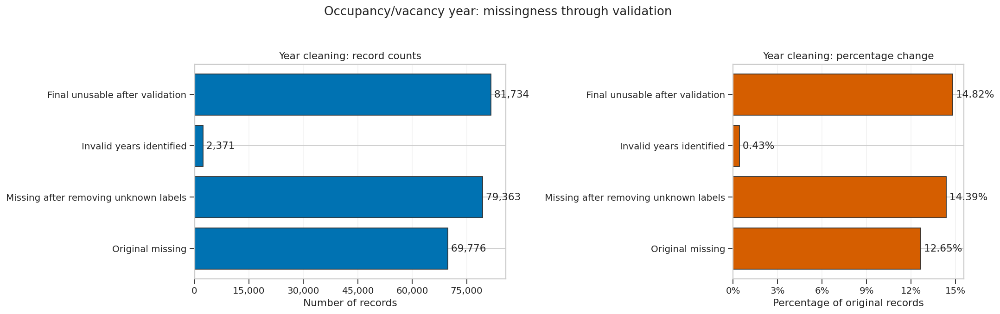

In [22]:
# Show how the year field changes at each cleaning stage.
# Percentages use the original dataset size, so stages are comparable.
denominator = max(len(df), 1)
year_stage = pd.DataFrame({
    "stage": [
        "Original missing",
        "Missing after removing unknown labels",
        "Invalid years identified",
        "Final unusable after validation",
    ],
    "count": [
        int(original_nan),
        int(nan_values_after_removing_unknown),
        int(total_invalid_years),
        int(total_unusable_before),
    ],
})
year_stage["percentage_of_records"] = year_stage["count"] / denominator * 100
display(year_stage)

from matplotlib.ticker import MaxNLocator, StrMethodFormatter
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={"width_ratios": [1.35, 1]})
bars = axes[0].barh(year_stage["stage"], year_stage["count"], color="#0072B2", edgecolor="#333333")
axes[0].set_xlabel("Number of records")
axes[0].set_title("Year cleaning: record counts")
axes[0].grid(axis="x", alpha=.25)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
axes[0].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[0].tick_params(axis="both", which="major", length=6, width=1)
for bar, value in zip(bars, year_stage["count"]):
    axes[0].text(bar.get_width(), bar.get_y() + bar.get_height()/2, f" {value:,}", va="center")

bars = axes[1].barh(year_stage["stage"], year_stage["percentage_of_records"], color="#D55E00", edgecolor="#333333")
axes[1].set_xlabel("Percentage of original records")
axes[1].set_title("Year cleaning: percentage change")
axes[1].grid(axis="x", alpha=.25)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[1].xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}%"))
axes[1].tick_params(axis="both", which="major", length=6, width=1)
for bar, value in zip(bars, year_stage["percentage_of_records"]):
    axes[1].text(bar.get_width(), bar.get_y() + bar.get_height()/2, f" {value:.2f}%", va="center")

fig.suptitle("Occupancy/vacancy year: missingness through validation")
plt.tight_layout(pad=2.0); plt.show()


### Invalid year values were reclassified as missing

The original missing count and the final unusable count are reported separately. Invalid years are not imputed unless a valid date-derived year is available; missing target values are dropped before EDA.


In [24]:
# Dataset Notes:
#Each row is a unit. To count total units, first select a year then count unique ids.
#Do not sum unit count
#Dropping unit_count since it is unrealibale to count total units

cleaned = cleaned.drop(columns=["unit_count"], errors="ignore")
print("unit_count" in cleaned.columns)

False


In [25]:
# Check missing IDs or duplicated unique_id's
print(
    "Missing unique_id values:",
    int(cleaned["unique_id"].isna().sum())
)

# Identify repeated IDs
duplicate_id_mask = (
    cleaned["unique_id"]
    .duplicated(keep=False)
)

print(
    "Rows with repeated unique_id:",
    int(duplicate_id_mask.sum())
)

print(
    "Number of duplicated unique_id values:",
    int(
        cleaned.loc[
            duplicate_id_mask,
            "unique_id"
        ].nunique()
    )
)

Missing unique_id values: 0
Rows with repeated unique_id: 65265
Number of duplicated unique_id values: 30984


In [26]:
#Drop unique_id since no duplicates and cannot be used for analysis
cleaned = cleaned.drop(
    columns=["unique_id"],
    errors="ignore"
)

In [27]:
#Creating S.NO but will be excluded from correlation matrix. Used for aggregation queries only

cleaned = cleaned.reset_index(drop=True)

cleaned["s_no"] = (
    cleaned.index + 1
)

In [28]:
#Inspect block_num column for missing and blank values

missing = int(cleaned['block_num'].isna().sum())

blank = int(
    (
       cleaned['block_num'].notna()
        & cleaned['block_num'].str.strip().eq("")
    ).sum()
)

print("Missing block_num:", missing)
print("Blank block_num:", blank)

display(
    cleaned["block_num"]
    .value_counts(dropna=False)
    .head(20)
)

Missing block_num: 2
Blank block_num: 0


block_num
8711     4542
3702     4264
3702A    4251
7335     3428
7282     3369
0198     2993
0305     2970
3783     2789
0731     2673
0318     2601
3547     2507
3738     2381
0200     2302
0274     2301
7326     2295
0337     2294
0303     2194
3750     2177
3833     2164
0281     2140

## Step 6 — Keep residential records

In [30]:
residential_types = [
    'Occupied by non-owner',
    'Occupied by owner',
    'Vacant'
]

cleaned = cleaned[
    cleaned['occupancy_type'].isin(residential_types)
].copy()

print('Shape after residential filtering:', cleaned.shape)

Shape after residential filtering: (548919, 25)


In [31]:
# Derive a readable street name before removing the detailed block address.
if "block_address" in cleaned.columns:
    cleaned["street_name"] = (
        cleaned["block_address"].astype("string")
        .str.lower()
        .str.replace(r"^.*block\s+of\s+", "", regex=True)
        .str.strip().str.upper()
    )
else:
    cleaned["street_name"] = pd.NA
print("Missing street names:", int(cleaned["street_name"].isna().sum()))


Missing street names: 76


In [32]:
display(
    cleaned[
        ["block_address", "street_name"]
    ].head(20)
)

                   block_address      street_name
0       400 Block of STOCKTON ST      STOCKTON ST
1          0 Block of STANYAN ST       STANYAN ST
2      300 Block of BRIGHTON AVE     BRIGHTON AVE
3      1300 Block of LA PLAYA ST      LA PLAYA ST
4      300 Block of BRIGHTON AVE     BRIGHTON AVE
5       400 Block of STOCKTON ST      STOCKTON ST
6      300 Block of BRIGHTON AVE     BRIGHTON AVE
7       400 Block of STOCKTON ST      STOCKTON ST
8        1200 Block of HAIGHT ST        HAIGHT ST
10                          <NA>             <NA>
11       1200 Block of HAIGHT ST        HAIGHT ST
12     1300 Block of LA PLAYA ST      LA PLAYA ST
13      400 Block of STOCKTON ST      STOCKTON ST
14     300 Block of BRIGHTON AVE     BRIGHTON AVE
15  500 Block of BUENA VISTA AVE  BUENA VISTA AVE
16          0 Block of ROMOLO ST        ROMOLO ST
17     1300 Block of LA PLAYA ST      LA PLAYA ST
18  500 Block of BUENA VISTA AVE  BUENA VISTA AVE
19     300 Block of BRIGHTON AVE     BRIGHTON AVE


In [33]:
#All missing street names are NA values
print(
    "Missing street names:",
    int(cleaned["street_name"].isna().sum())
)

Missing street names: 76


In [34]:
#Drop block address, since street names are derived
cleaned = cleaned.drop(
    columns=["block_address"],
    errors="ignore"
)

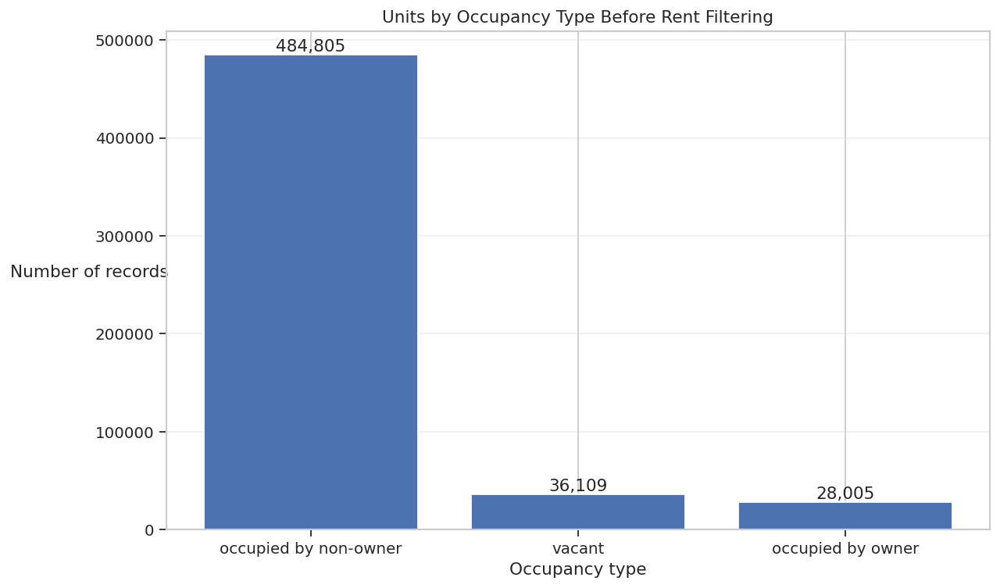

In [35]:
#inspect occupancy type
import pandas as pd
import matplotlib.pyplot as plt

occupancy_counts = (
    cleaned["occupancy_type"]
    .str.strip()
    .str.lower()
    .value_counts(dropna=False)
    .reset_index()
)

occupancy_counts.columns = [
    "occupancy_type",
    "record_count"
]


plt.figure(figsize=(10, 6))

bars = plt.bar(
    occupancy_counts["occupancy_type"].fillna("Missing"),
    occupancy_counts["record_count"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Occupancy type")
plt.ylabel("Number of records", rotation = 0)
plt.title("Units by Occupancy Type Before Rent Filtering")
plt.xticks(rotation=0, ha="center")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

          occupancy_type  total_rows  missing_rent  available_rent  missing_rent_percentage
0        Non-Residential        2632          2632               0                   100.00
2      Occupied by owner       28005         28005               0                   100.00
3                 Vacant       36109         33977            2132                    94.10
1  Occupied by non-owner      484805          1895          482910                     0.39

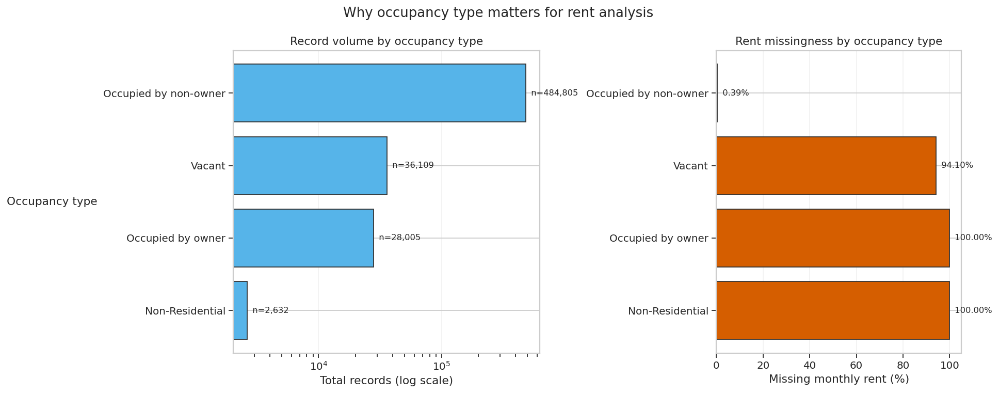

In [37]:
# Rent availability differs sharply by occupancy type in the original data.
rent_by_occupancy = (
    df.groupby("occupancy_type", dropna=False)
    .agg(
        total_rows=("monthly_rent", "size"),
        missing_rent=("monthly_rent", lambda x: x.isna().sum())
    )
    .reset_index()
)
rent_by_occupancy["occupancy_type"] = rent_by_occupancy["occupancy_type"].fillna("Missing")
rent_by_occupancy["available_rent"] = rent_by_occupancy["total_rows"] - rent_by_occupancy["missing_rent"]
rent_by_occupancy["missing_rent_percentage"] = (
    rent_by_occupancy["missing_rent"] / rent_by_occupancy["total_rows"] * 100
).round(2)
rent_by_occupancy = rent_by_occupancy.sort_values("total_rows", ascending=True)
display(rent_by_occupancy)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.25, 1]})
# A log x-axis keeps smaller occupancy groups visible beside the very large group.
axes[0].barh(rent_by_occupancy["occupancy_type"], rent_by_occupancy["total_rows"], color="#56B4E9", edgecolor="#333333")
axes[0].set_xscale("log")
axes[0].set_xlabel("Total records (log scale)")
axes[0].set_ylabel("Occupancy type", rotation=0, labelpad=55, va="center")
axes[0].set_title("Record volume by occupancy type")
axes[0].grid(axis="x", alpha=.25)
for y, (_, row) in enumerate(rent_by_occupancy.iterrows()):
    axes[0].text(row["total_rows"], y, f"  n={int(row['total_rows']):,}", va="center", fontsize=9)

axes[1].barh(rent_by_occupancy["occupancy_type"], rent_by_occupancy["missing_rent_percentage"], color="#D55E00", edgecolor="#333333")
axes[1].set_xlim(0, 105)
axes[1].set_xlabel("Missing monthly rent (%)")
axes[1].set_title("Rent missingness by occupancy type")
axes[1].grid(axis="x", alpha=.25)
for y, (_, row) in enumerate(rent_by_occupancy.iterrows()):
    axes[1].text(row["missing_rent_percentage"], y, f"  {row['missing_rent_percentage']:.2f}%", va="center", fontsize=9)

fig.suptitle("Why occupancy type matters for rent analysis")
plt.tight_layout(); plt.show()


## Interpretation of rent availability by occupancy type

The left panel compares the number of records on a logarithmic scale because the occupied-by-non-owner group is much larger than the other groups. The right panel shows the key data-quality difference: non-residential and occupied-by-owner records have 100% missing rent, vacant records have 94.10% missing rent, while occupied-by-non-owner records have only 0.39% missing rent. Therefore, the rent analysis is restricted to the occupancy groups that can provide usable rent observations. This is a data-availability decision, not evidence that occupancy type causes rent values.


In [39]:
exclude_occupancy_types = [
    "non-residential",
    "occupied by owner"
]

occupancy_type = (
    cleaned["occupancy_type"]
    .str.strip()
    .str.lower()
)

cleaned = cleaned[
    ~occupancy_type.isin(exclude_occupancy_types)
].copy()

In [40]:
#after removal of non-residential and owner occupancy type
print("Rows remaining in cleaned:", len(cleaned))
print("Rows in df:", len(df))

Rows remaining in cleaned: 520914
Rows in df: 551551


In [41]:
display(
    cleaned["monthly_rent"]
    .value_counts(dropna=False)
    .head(30)
)

monthly_rent
$2251-$2500                          41151
$1751-$2000                          40284
$2751-$3000                          38510
$2501-$2750                          36980
$2001-$2250                          36829
$1501-$1750                          36263
<NA>                                 35872
$1251-$1500                          31845
$3001-$3250                          29590
$3251-$3500                          27843
$1001-$1250                          26964
$751-$1000                           18794
$3501-$3750                          18031
$3751-$4000                          17121
$501-$750                            16600
$4001-$4250                          10968
$4251-$4500                          10210
$4751-$5000                           7127
$4501-$4750                           6559
$251-$500                             6063
$7000+                                4053
$5001-$5250                           3985
$5251-$5500                           362

In [42]:
# Convert monthly-rent ranges to numeric bounds and a target midpoint
rent_text = (
    cleaned["monthly_rent"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)

rent_parts = rent_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*[-–]\s*(\d+(?:\.\d+)?)",
    expand=True
)
rent_parts.columns = ["rent_lower_bound", "rent_upper_bound"]

rent_lower_bound = pd.to_numeric(
    rent_parts["rent_lower_bound"], errors="coerce"
)
rent_upper_bound = pd.to_numeric(
    rent_parts["rent_upper_bound"], errors="coerce"
)

# Handle open-ended values such as 7000+ only.
plus_mask = rent_text.str.contains("+", regex=False, na=False)
plus_value = pd.to_numeric(
    rent_text.where(plus_mask)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce"
)
rent_lower_bound = rent_lower_bound.fillna(plus_value)

# Handle explicit zero-rent text without treating other values as zero.
zero_text_mask = rent_text.str.fullmatch(
    r"0(?:\.0+)?|no rent paid", na=False
)
rent_lower_bound = rent_lower_bound.mask(zero_text_mask, 0)

monthly_rent_midpoint = (rent_lower_bound + rent_upper_bound) / 2
# For open-ended values such as 7000+, use the known lower bound.
monthly_rent_midpoint = monthly_rent_midpoint.fillna(plus_value)
monthly_rent_midpoint = monthly_rent_midpoint.mask(zero_text_mask, 0)

cleaned["rent_lower_bound"] = rent_lower_bound
cleaned["rent_upper_bound"] = rent_upper_bound
cleaned["monthly_rent_midpoint"] = monthly_rent_midpoint

print("Missing target rows before dropping:", int(cleaned["monthly_rent_midpoint"].isna().sum()))
print("Missing target percentage:", round(cleaned["monthly_rent_midpoint"].isna().mean() * 100, 2))


Missing target rows before dropping: 39461
Missing target percentage: 7.58


## Step 18 — Standardize bedroom and bathroom categories

The original text values are preserved for audit. Blank and missing values remain `NaN`; valid zero values remain `0`; known labels are harmonized; and other non-missing labels are grouped as `Other`. These cleaned categories are used throughout the EDA below.


In [44]:
# Preserve the pre-standardization values for before/after validation.
cleaned["bedroom_count_before_standardization"] = cleaned["bedroom_count"].copy()
cleaned["bathroom_count_before_standardization"] = cleaned["bathroom_count"].copy()

bedroom_map = {
    "studio": "Studio",
    "studio (sm)": "Studio",
    "zero -(studio)": "Studio",
    "zero-(studio)": "Studio",
    "one-bedroom": "One-Bedroom",
    "one bedroom": "One-Bedroom",
    "1": "One-Bedroom",
    "1 bedroom": "One-Bedroom",
    "1br": "One-Bedroom",
    "1 bed": "One-Bedroom",
    "two-bedroom": "Two-Bedroom",
    "two bedroom": "Two-Bedroom",
    "2": "Two-Bedroom",
    "2 bedroom": "Two-Bedroom",
    "2br": "Two-Bedroom",
    "2a": "Two-Bedroom",
    "2s": "Two-Bedroom",
    "2brd": "Two-Bedroom",
    "2u": "Two-Bedroom",
    "2t": "Two-Bedroom",
    "2 bedriin": "Two-Bedroom",
    "2 bedroomq": "Two-Bedroom",
    "three-bedroom": "Three-Bedroom",
    "three bedroom": "Three-Bedroom",
    "3": "Three-Bedroom",
    "3 bedroom": "Three-Bedroom",
    "3bedroom": "Three-Bedroom",
    "four-bedroom": "Four-Bedroom",
    "four bedroom": "Four-Bedroom",
    "4": "Four-Bedroom",
    "5+": "5+",
    "five-bedroom": "5+",
    "0": "Studio",
}

bathroom_map = {
    "one bathroom": "1", "1": "1",
    "one-bathroom": "1", "1.00": "1",
    "1 bathroom": "1", "1bathroom": "1",
    "two bathrooms": "2", "2": "2",
    "two bathroom": "2", "2 bathroom": "2",
    "2.00": "2", "two-bathroom": "2",
    "2 batroom": "2",
    "one and a half bathrooms": "1.5",
    "one and a half bathroom": "1.5",
    "one and a half bathdrooms": "1.5",
    "two and a half bathrooms": "2.5", "2.5": "2.5",
    "three bathrooms or more": "3+", "3.5": "3+",
    "shared bathroom facilities with other units": "Shared",
    "0": "0",
}

def standardize_category(series, mapping):
    normalized = series.astype("string").str.strip().str.lower()
    missing_tokens = normalized.isna() | normalized.isin(["", "nan", "none", "na", "n/a", "<na>"])
    result = normalized.map(mapping)
    result = result.mask(missing_tokens, pd.NA)
    result = result.mask(~missing_tokens & result.isna(), "Other")
    return result.astype("string")

cleaned["bedroom_count"] = standardize_category(cleaned["bedroom_count_before_standardization"], bedroom_map)
cleaned["bathroom_count"] = standardize_category(cleaned["bathroom_count_before_standardization"], bathroom_map)

print("Bedroom categories after standardization:")
display(cleaned["bedroom_count"].value_counts(dropna=False).to_frame("record_count"))
print("Bathroom categories after standardization:")
display(cleaned["bathroom_count"].value_counts(dropna=False).to_frame("record_count"))

print("Raw bathroom zero-label records for review:", int((cleaned["bathroom_count_before_standardization"].astype("string").str.strip() == "0").sum()))
print("Standardized bathroom zero-label records retained for audit:", int((cleaned["bathroom_count"] == "0").sum()))


Bedroom categories after standardization:
Bathroom categories after standardization:
Raw bathroom zero-label records for review: 91
Standardized bathroom zero-label records retained for audit: 91


               record_count
bedroom_count              
One-Bedroom          210512
Studio               141735
Two-Bedroom          128616
Three-Bedroom         30294
Four-Bedroom           6234
<NA>                   1888
5+                     1611
Other                    24

                record_count
bathroom_count              
1                     418071
2                      60756
Shared                 20804
1.5                    10864
3+                      4663
2.5                     3953
<NA>                    1692
0                         91
Other                     20

## Step 10 — Convert utility values to binary values

In [46]:
utility_columns = [
    'base_rent_includes_water_sewer',
    'base_rent_includes_natural_gas',
    'base_rent_includes_electricity',
    'base_rent_includes_refuse_recycling',
    'base_rent_includes_other_utilities'
]

for col in utility_columns:
    if col in cleaned.columns:
        cleaned[col] = cleaned[col].map({'Y': 1, 'N': 0})

print('Utility columns converted.')

Utility columns converted.


## Step 13 — Create a midpoint conversion function

In [48]:
# Convert square-footage text to a numeric analysis feature.
def square_footage_midpoint(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower().replace(",", "")
    if text in {"", "unknown", "none", "nan", "na", "n/a"}:
        return np.nan
    numbers = [float(x) for x in re.findall(r"\d+(?:\.\d+)?", text)]
    if not numbers:
        return np.nan
    if "+" in text:
        return numbers[0]
    if len(numbers) >= 2:
        return (numbers[0] + numbers[1]) / 2
    return numbers[0]

cleaned["square_footage_midpoint"] = cleaned["square_footage"].apply(square_footage_midpoint)
print("Missing square-footage values:", int(cleaned["square_footage_midpoint"].isna().sum()))


Missing square-footage values: 11940


## Step 15 — Convert square footage to a numeric feature

In [50]:
cleaned['square_footage'].value_counts(dropna=False)


## Step 16 — Create property age

In [52]:
# Derive property age only when both year fields are available.
if {"year_property_built", "submission_year"}.issubset(cleaned.columns):
    cleaned.loc[
        (cleaned['year_property_built'] < 1800) |
        (cleaned['year_property_built'] > cleaned['submission_year']),
        'year_property_built'
    ] = np.nan
    cleaned['property_age'] = cleaned['submission_year'] - cleaned['year_property_built']
    cleaned.loc[(cleaned['property_age'] < 0) | (cleaned['property_age'] > 300), 'property_age'] = np.nan
else:
    cleaned['property_age'] = np.nan
print(cleaned['property_age'].describe())


count    505100.000000
mean         83.445749
std          35.511083
min           1.000000
25%          60.000000
50%          98.000000
75%         113.000000
max         217.000000
Name: property_age, dtype: float64


## Step 17 — Create the bivariate analysis dataset

In [54]:
# Convert past_occupancy to binary values

cleaned["past_occupancy"] = (
    cleaned["past_occupancy"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map({
        "Y": 1,
        "YES": 1,
        "N": 0,
        "NO": 0
    })
    .astype("Int64")
)

# Check results
print(cleaned["past_occupancy"].value_counts(dropna=False))

past_occupancy
0       312487
<NA>    125503
1        82924
Name: count, dtype: Int64


In [55]:
import numpy as np

cleaned["analysis_neighborhood"] = (
    cleaned["analysis_neighborhood"]
    .astype("object")
    .str.strip()
)

# Convert blanks and missing text to NaN
cleaned["analysis_neighborhood"] = (
    cleaned["analysis_neighborhood"]
    .replace(
        ["", "nan", "none", "na", "n/a", "unknown"],
        np.nan
    )
)

# Check result
print(cleaned["analysis_neighborhood"].isna().sum())
print(cleaned["analysis_neighborhood"].value_counts(dropna=False))

14
analysis_neighborhood
Nob Hill                          49571
Tenderloin                        41790
Mission                           39114
Marina                            30537
Pacific Heights                   30508
Financial District/South Beach    23673
Russian Hill                      22787
South of Market                   22201
Western Addition                  22073
Hayes Valley                      21403
Lakeshore                         20970
Outer Richmond                    19401
Chinatown                         17063
Castro/Upper Market               16777
Inner Sunset                      14624
Haight Ashbury                    13770
Mission Bay                       13441
Sunset/Parkside                   12733
Inner Richmond                    12393
North Beach                       11812
Noe Valley                         9664
Lone Mountain/USF                  8766
Potrero Hill                       8104
Presidio Heights                   7037
Twin Peaks     

In [56]:
import pandas as pd
import numpy as np

# Keep the original values temporarily
signature_raw = (
    cleaned["signature_date"]
    .astype("string")
    .str.strip()
)

# Treat blank and missing text as missing
missing_labels = ["", "nan", "none", "na", "n/a", "unknown"]

missing_mask = (
    signature_raw.isna() |
    signature_raw.str.lower().isin(missing_labels)
)

# Convert valid dates; invalid dates become NaT
signature_parsed = pd.to_datetime(
    signature_raw.where(~missing_mask),
    errors="coerce",
    format="mixed"
)

# Identify invalid non-missing values
invalid_mask = (
    signature_parsed.isna() &
    ~missing_mask
)

print("Missing signature dates:", missing_mask.sum())
print("Invalid signature dates:", invalid_mask.sum())

print("\nInvalid values:")
print(signature_raw[invalid_mask].value_counts())

# Store cleaned datetime column
cleaned["signature_date"] = signature_parsed

# Check final result
print("\nFinal missing/invalid values:",
      cleaned["signature_date"].isna().sum())

print("Datatype:",
      cleaned["signature_date"].dtype)

Missing signature dates: 127
Invalid signature dates: 0

Invalid values:
Series([], Name: count, dtype: Int64)

Final missing/invalid values: 127
Datatype: datetime64[ns]


In [57]:
# 1. Check datatype
print("Datatype:")
print(cleaned["signature_date"].dtype)

# 2. Count missing or invalid dates
print("\nMissing/invalid dates:")
print(cleaned["signature_date"].isna().sum())

# 3. Check valid date range
print("\nEarliest signature date:")
print(cleaned["signature_date"].min())

print("\nLatest signature date:")
print(cleaned["signature_date"].max())

# 4. Display cleaned values
display(
    cleaned[["signature_date"]]

)

# 5. Check whether invalid original values remain
print("\nOriginal invalid values:")
print(signature_raw[invalid_mask].value_counts())

Datatype:
datetime64[ns]

Missing/invalid dates:
127

Earliest signature date:
1974-04-26 00:00:00

Latest signature date:
2026-12-02 00:00:00

Original invalid values:
Series([], Name: count, dtype: Int64)


       signature_date
0          2022-07-28
2          2022-06-30
3          2023-10-13
4          2023-02-28
5          2025-02-21
6          2023-02-28
7          2022-07-28
8          2026-02-09
10         2023-03-22
11         2026-06-13
12         2022-06-28
13         2023-02-24
14         2026-02-27
15         2023-11-29
16         2026-01-27
17         2022-06-28
18         2024-10-13
19         2026-02-27
20         2024-03-01
21         2026-02-27
22         2024-03-01
24         2026-02-23
25         2022-06-28
26         2024-03-01
27         2023-03-06
28         2024-03-01
29         2024-02-18
30         2022-07-28
31         2025-02-23
32         2025-02-27
33         2026-02-23
34         2025-02-23
35         2025-02-22
36         2022-06-24
37         2022-10-26
38         2025-10-03
39         2025-02-25
40         2026-02-27
41         2026-02-27
42         2023-02-28
43         2022-06-28
44         2025-02-21
45         2024-02-13
46         2025-11-26
47        

In [58]:
print(cleaned["signature_date"].isna().sum())
print(cleaned["signature_date"].dtype)

127
datetime64[ns]


# Integrated EDA: Univariate, Bivariate, and Multivariate Analysis

This EDA uses the cleaned dataframe after the documented validation and transformations. It examines the rent target, important categorical and numeric features, relationships with rent, and the decisions needed before modeling.


In [60]:
# Final descriptive-analysis dataset: missing target rows are dropped, never imputed.
df_clean = cleaned.copy()
target = "monthly_rent_midpoint"
rows_before_target_drop = len(df_clean)
eda_with_zero_rent = df_clean.dropna(subset=[target]).copy()
zero_rent_mask = eda_with_zero_rent[target] <= 0
zero_rent_count = int(zero_rent_mask.sum())
zero_rent_percentage = round(zero_rent_mask.mean() * 100, 2) if len(eda_with_zero_rent) else 0
eda = eda_with_zero_rent.loc[~zero_rent_mask].copy()
rows_removed_for_target = int(df_clean[target].isna().sum())
rows_removed_for_zero_rent = zero_rent_count
print("Rows before target filtering:", rows_before_target_drop)
print("Rows removed because rent target was missing:", rows_removed_for_target)
print(f"Zero/non-positive rent rows retained only for audit: {zero_rent_count:,} ({zero_rent_percentage:.2f}%)")
print("Final EDA rows with positive rent only:", len(eda))
zero_rent_audit = pd.DataFrame({"group": ["Missing rent", "Zero/non-positive rent", "Positive rent used for EDA"], "records": [rows_removed_for_target, zero_rent_count, len(eda)]})
display(zero_rent_audit)
print("Target mean:", round(eda[target].mean(), 2))
print("Target median:", round(eda[target].median(), 2))
print("Target skewness:", round(eda[target].skew(), 2))


Rows before target filtering: 520914
Rows removed because rent target was missing: 39461
Zero/non-positive rent rows retained only for audit: 6 (0.00%)
Final EDA rows with positive rent only: 481447
Target mean: 2540.2
Target median: 2375.5
Target skewness: 0.85


                        group  records
0                Missing rent    39461
1      Zero/non-positive rent        6
2  Positive rent used for EDA   481447

## EDA analysis after cleaning validation

The following tables and statistics establish findings from the cleaned data first. The question-led visualizations then show the distributions and relationships identified by those summaries.


## Cleaning validation before EDA

These checks verify that the cleaned fields are suitable for descriptive analysis and identify any remaining domain problems before interpreting relationships.


In [63]:
target = "monthly_rent_midpoint"
cleaning_checks = pd.DataFrame({
    "check": [
        "negative rent target",
        "zero rent target",
        "non-positive square footage",
        "invalid property age",
        "duplicate analysis rows",
    ],
    "count": [
        int((cleaned[target] < 0).sum()),
        int((cleaned[target] == 0).sum()),
        int((cleaned["square_footage_midpoint"] <= 0).sum()),
        int(((cleaned["property_age"] < 0) | (cleaned["property_age"] > 300)).sum()),
        int(cleaned.duplicated().sum()),
    ],
})
display(cleaning_checks)
print("Remaining missingness by field:")
display(cleaned[[target, "square_footage_midpoint", "property_age", "bedroom_count", "bathroom_count", "analysis_neighborhood"]].isna().sum().to_frame("missing_count"))


Remaining missingness by field:


                         check  count
0         negative rent target      0
1             zero rent target      6
2  non-positive square footage      0
3         invalid property age      0
4      duplicate analysis rows      0

                         missing_count
monthly_rent_midpoint            39461
square_footage_midpoint          11940
property_age                     15814
bedroom_count                     1888
bathroom_count                    1692
analysis_neighborhood               14

In [64]:
# Tables used to choose and support the visualizations.
numeric_summary_columns = [c for c in [target, "square_footage_midpoint", "property_age"] if c in eda.columns]
display(eda[numeric_summary_columns].describe().T)
for col in ["bedroom_count", "bathroom_count", "occupancy_type", "submission_type", "supervisor_district"]:
    if col in eda.columns:
        print(f"\n{col} distribution")
        display(eda[col].value_counts(dropna=False).head(20).to_frame("record_count"))

bedroom_rent_summary = (
    eda.dropna(subset=["bedroom_count"])
    .groupby("bedroom_count", observed=False)[target]
    .agg(record_count="count", median_rent="median", mean_rent="mean")
    .sort_values("median_rent", ascending=False)
)
display(bedroom_rent_summary)



bedroom_count distribution

bathroom_count distribution

occupancy_type distribution

supervisor_district distribution


                            count         mean          std    min     25%     50%     75%     max
monthly_rent_midpoint    481447.0  2540.196935  1276.800863  125.5  1625.5  2375.5  3125.5  7000.0
square_footage_midpoint  470893.0   722.225893   381.636412  125.0   375.5   625.5   875.5  4000.0
property_age             467433.0    83.019926    35.617106    1.0    59.0    97.0   113.0   217.0

               record_count
bedroom_count              
One-Bedroom          196571
Studio               129214
Two-Bedroom          119774
Three-Bedroom         27995
Four-Bedroom           5736
5+                     1352
<NA>                    781
Other                    24

                record_count
bathroom_count              
1                     390862
2                      56292
Shared                 16080
1.5                    10198
3+                      4004
2.5                     3465
<NA>                     444
0                         83
Other                     19

                       record_count
occupancy_type                     
Occupied by non-owner        479853
Vacant                         1594

                     record_count
supervisor_district              
3.0                        106387
2.0                         73574
5.0                         71902
6.0                         52822
8.0                         48086
1.0                         32870
7.0                         32702
9.0                         30833
10.0                        13327
4.0                         12134
11.0                         6800
<NA>                           10

               record_count  median_rent    mean_rent
bedroom_count                                        
5+                     1352       6375.5   5594.70895
Four-Bedroom           5736       4875.5  4741.687326
Three-Bedroom         27995       4125.5  4067.800947
Two-Bedroom          119774       3125.5  3205.749537
One-Bedroom          196571       2375.5  2418.494239
Other                    24       2375.5  2427.583333
Studio               129214       1625.5  1657.334449

## Optional RAPIDS acceleration

RAPIDS is used here for numeric summaries and grouped calculations when a compatible GPU environment is available. The resulting small tables are converted back to pandas for plotting.


In [66]:
try:
    import cudf
    rapids_available = True
except ImportError:
    rapids_available = False
    print("RAPIDS is unavailable; CPU summaries remain the reference analysis.")

if rapids_available:
  try:
    gpu_numeric = cudf.from_pandas(
        eda[[target, "square_footage_midpoint", "property_age"]].copy()
    )
    print("RAPIDS numeric summary:")
    display(gpu_numeric.describe().to_pandas())

    gpu_bedroom = cudf.from_pandas(
        eda[["bedroom_count", target]].dropna().copy()
    )
    gpu_bedroom_summary = (
        gpu_bedroom.groupby("bedroom_count")[target]
        .agg(["count", "mean", "median"])
        .reset_index()
        .to_pandas()
    )
    display(gpu_bedroom_summary)
  except Exception as exc:
    print(f"RAPIDS computation was skipped because the current cuDF environment could not process these columns: {exc}")


RAPIDS is unavailable; CPU summaries remain the reference analysis.


## EDA visualizations linked to the cleaned data

Each visual below is computed from `eda`, which is created from `cleaned` after the target and feature validation steps. Every chart states the question it is intended to answer.


## Univariate analysis

Univariate analysis examines the target distribution and the distribution of important categorical features.


## Visualization 1 — Target distribution

**Question:** What is the shape of monthly rent, and is it skewed?


**Interpretation:** The full-range histogram preserves the complete positive-rent distribution, while the adjacent 99% view makes the central shape easier to read. Compare the mean and median, then use the reported skewness and full-range outliers together: a higher mean and long upper tail indicate right-skewed rent rather than a symmetric distribution.


The histogram is capped only for readability; the boxplot uses positive rents and displays IQR outliers.


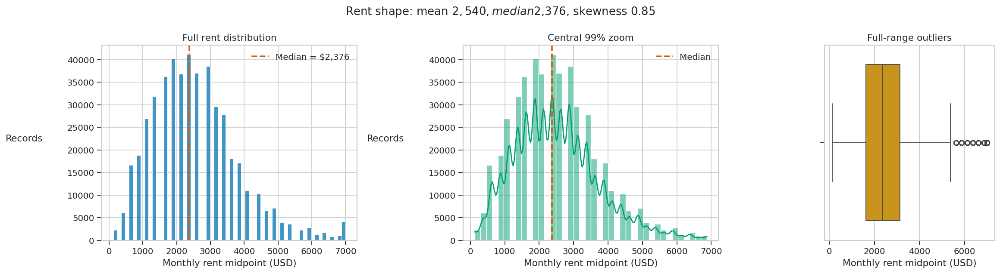

In [71]:
plot_rent = eda[target].dropna()
rent_cap = plot_rent.quantile(0.99)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"width_ratios": [1.2, 1.2, .8]})
sns.histplot(plot_rent, bins=60, color="#0072B2", ax=axes[0])
axes[0].axvline(plot_rent.median(), color="#D55E00", linestyle="--", linewidth=2, label=f"Median = ${plot_rent.median():,.0f}")
axes[0].set(title="Full rent distribution", xlabel="Monthly rent midpoint (USD)", ylabel="Records")
axes[0].yaxis.label.set_rotation(0); axes[0].yaxis.labelpad = 55
axes[0].legend(frameon=False)
sns.histplot(plot_rent[plot_rent <= rent_cap], bins=40, kde=True, color="#009E73", ax=axes[1])
axes[1].axvline(plot_rent.median(), color="#D55E00", linestyle="--", linewidth=2, label="Median")
axes[1].set(title="Central 99% zoom", xlabel="Monthly rent midpoint (USD)", ylabel="Records")
axes[1].yaxis.label.set_rotation(0); axes[1].yaxis.labelpad = 55
axes[1].legend(frameon=False)
sns.boxplot(x=plot_rent, ax=axes[2], color="#E69F00", showfliers=True)
axes[2].set(title="Full-range outliers", xlabel="Monthly rent midpoint (USD)")
for ax in axes:
    ax.tick_params(axis="both", which="major", length=6, width=1)
fig.suptitle(f"Rent shape: mean ${plot_rent.mean():,.0f}, median ${plot_rent.median():,.0f}, skewness {plot_rent.skew():.2f}")
plt.tight_layout(); plt.show()
print("The histogram is capped only for readability; the boxplot uses positive rents and displays IQR outliers.")


## Outlier check and high-rent row inspection

Boxplots use two views: the grouped comparison plots hide individual fliers to remain readable, while this section explicitly calculates and displays IQR-based rent outliers. An outlier here means a value outside 1.5 × IQR; it is not automatically an error. The inspection table displays the highest-rent rows and their raw housing fields so plausible expensive units can be separated from data-entry or parsing errors before any removal decision.


Interpretation: 13,807 records (2.87%) fall outside the IQR fences. They are retained for descriptive analysis unless domain validation identifies them as errors.
Rows flagged for review: 13,807; top 1% cutoff: $6,876


       Q1      Q3     IQR  lower_fence  upper_fence  outlier_count  outlier_percentage
0  1625.5  3125.5  1500.0            0       5375.5          13807                2.87

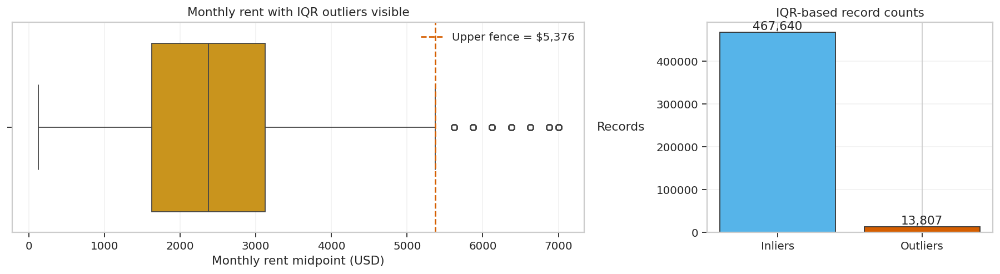

           unique_id monthly_rent                  block_address         occupancy_type  bedroom_count                               bathroom_count   square_footage           analysis_neighborhood  supervisor_district  year_property_built occupancy_or_vacancy_date  submission_year  monthly_rent_midpoint       street_name  square_footage_midpoint  property_age          review_reason
3734    7.197416e+18       $7000+          0 Block of DOLORES ST  Occupied by non-owner  Three-Bedroom                                Two bathrooms  1501-1750 Sq.Ft             Castro/Upper Market                  8.0               2014.0                 6/17/2023             2024                 7000.0        DOLORES ST                   1625.5          10.0  Above IQR upper fence
207     7.749825e+18       $7000+       100 Block of PACIFIC AVE  Occupied by non-owner  Three-Bedroom                      Three bathrooms or more  1751-2000 Sq.Ft                       Chinatown                  3.0             

In [73]:
rent_for_outliers = eda[target].dropna().astype(float)
q1, q3 = rent_for_outliers.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = max(0, q1 - 1.5 * iqr)
upper_fence = q3 + 1.5 * iqr
outlier_mask = (rent_for_outliers < lower_fence) | (rent_for_outliers > upper_fence)
outlier_summary = pd.DataFrame({
    "Q1": [q1], "Q3": [q3], "IQR": [iqr],
    "lower_fence": [lower_fence], "upper_fence": [upper_fence],
    "outlier_count": [int(outlier_mask.sum())],
    "outlier_percentage": [round(outlier_mask.mean() * 100, 2)],
})
display(outlier_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.boxplot(x=rent_for_outliers, showfliers=True, color="#E69F00", ax=axes[0])
axes[0].axvline(upper_fence, color="#D55E00", linestyle="--", label=f"Upper fence = ${upper_fence:,.0f}")
axes[0].set_title("Monthly rent with IQR outliers visible")
axes[0].set_xlabel("Monthly rent midpoint (USD)")
axes[0].legend(frameon=False)
axes[0].grid(axis="x", alpha=.25)
inlier_count = int((~outlier_mask).sum())
outlier_count = int(outlier_mask.sum())
axes[1].bar(["Inliers", "Outliers"], [inlier_count, outlier_count], color=["#56B4E9", "#D55E00"], edgecolor="#333333")
axes[1].set_title("IQR-based record counts")
axes[1].set_ylabel("Records", rotation=0, labelpad=35, va="center")
axes[1].grid(axis="y", alpha=.25)
for x, value in enumerate([inlier_count, outlier_count]):
    axes[1].text(x, value, f"{value:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"Interpretation: {outlier_count:,} records ({outlier_mask.mean()*100:.2f}%) fall outside the IQR fences. They are retained for descriptive analysis unless domain validation identifies them as errors.")

# Inspect actual high-rent rows before deciding whether any extreme value is invalid.
top_one_percent_cutoff = rent_for_outliers.quantile(0.99)
high_rent_index = rent_for_outliers.index[(rent_for_outliers > upper_fence) | (rent_for_outliers >= top_one_percent_cutoff)]
raw_inspection_columns = [
    "unique_id", "monthly_rent", "block_address", "occupancy_type",
    "bedroom_count", "bathroom_count", "square_footage",
    "analysis_neighborhood", "supervisor_district", "year_property_built",
    "occupancy_or_vacancy_date", "submission_year",
]
inspection_columns = [c for c in raw_inspection_columns if c in df.columns]
high_rent_inspection = df.loc[df.index.intersection(high_rent_index), inspection_columns].copy()
for derived_column in [target, "street_name", "square_footage_midpoint", "property_age"]:
    if derived_column in eda.columns:
        high_rent_inspection[derived_column] = eda.loc[high_rent_inspection.index, derived_column]
high_rent_inspection["review_reason"] = np.where(
    high_rent_inspection[target] > upper_fence,
    "Above IQR upper fence",
    "Top 1% of positive rents",
)
high_rent_inspection = high_rent_inspection.sort_values(target, ascending=False).head(50)
print(f"Rows flagged for review: {len(high_rent_index):,}; top 1% cutoff: ${top_one_percent_cutoff:,.0f}")
display(high_rent_inspection)


## QQ plot for monthly rent

**Question:** Does the rent distribution approximately follow a normal distribution?

In a QQ plot, points close to the reference line indicate approximate normality. Systematic curvature and strong departures at the ends indicate skewness or heavy tails. For rent, a pronounced upper-tail departure is expected because a smaller number of high-rent observations extend beyond the central pattern. This plot supports the histogram and skewness statistic; it does not remove or repair outliers.


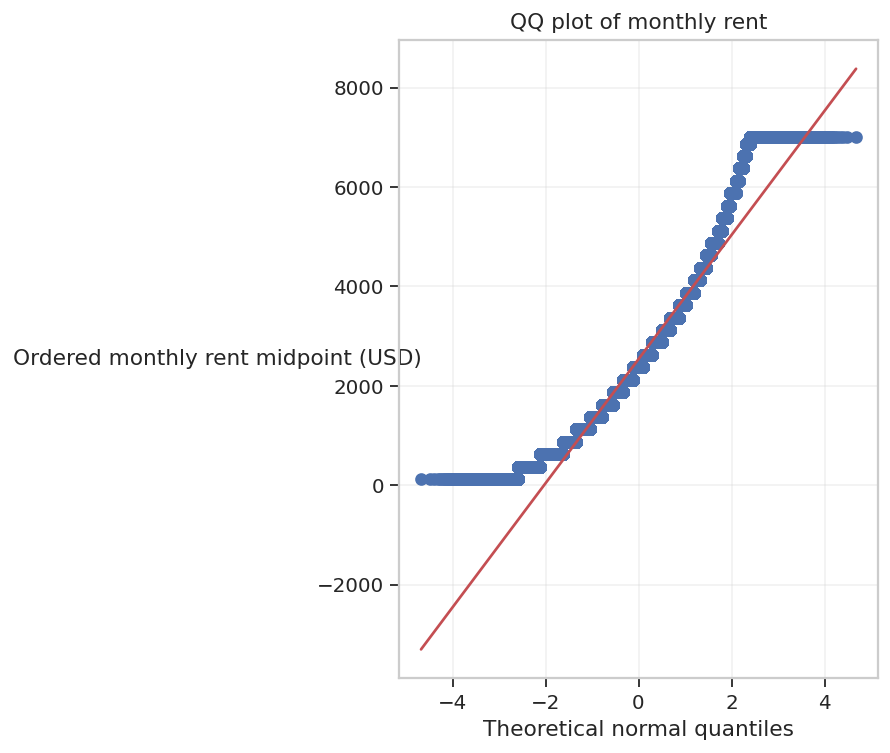

In [75]:
try:
    from scipy import stats
    fig, ax = plt.subplots(figsize=(7, 6))
    stats.probplot(plot_rent, dist="norm", plot=ax)
    ax.set_title("QQ plot of monthly rent")
    ax.set_xlabel("Theoretical normal quantiles")
    ax.set_ylabel("Ordered monthly rent midpoint (USD)", rotation=0, labelpad=55, va="center")
    ax.grid(alpha=.25)
    plt.tight_layout(); plt.show()
except ImportError:
    print("QQ plot skipped: scipy is not installed in this environment.")


## Visualization 2 — Bedroom composition

**Question:** What bedroom categories dominate the residential records?


**Interpretation:** This count chart identifies the dominant bedroom categories and whether rare categories may produce unstable rent comparisons. Counts should be considered alongside the later median-rent plot.


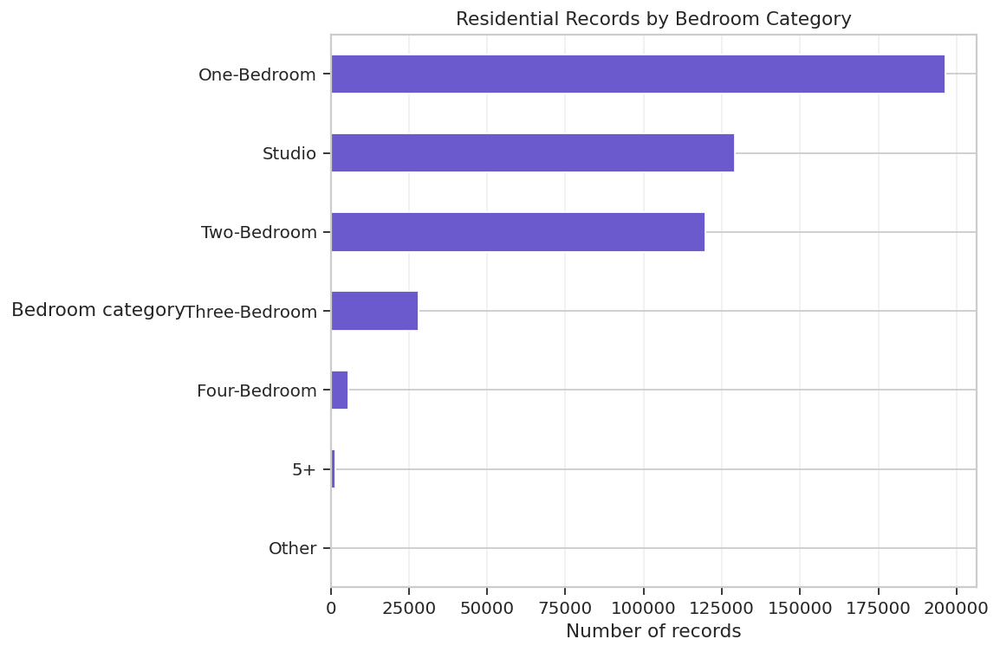

In [78]:
bedroom_counts = (
    eda["bedroom_count"]
    .dropna()
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 6))
bedroom_counts.plot(kind="barh", color="slateblue")
plt.xlabel("Number of records")
plt.ylabel("Bedroom category", rotation=0, labelpad=55, va="center")
plt.title("Residential Records by Bedroom Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization 3 — Bathroom composition

**Question:** What bathroom categories are most common, and which values require caution?**


**Interpretation:** This chart shows the frequency of bathroom categories. Rare, shared, or Other categories should be interpreted cautiously because their rent summaries may be based on fewer records.


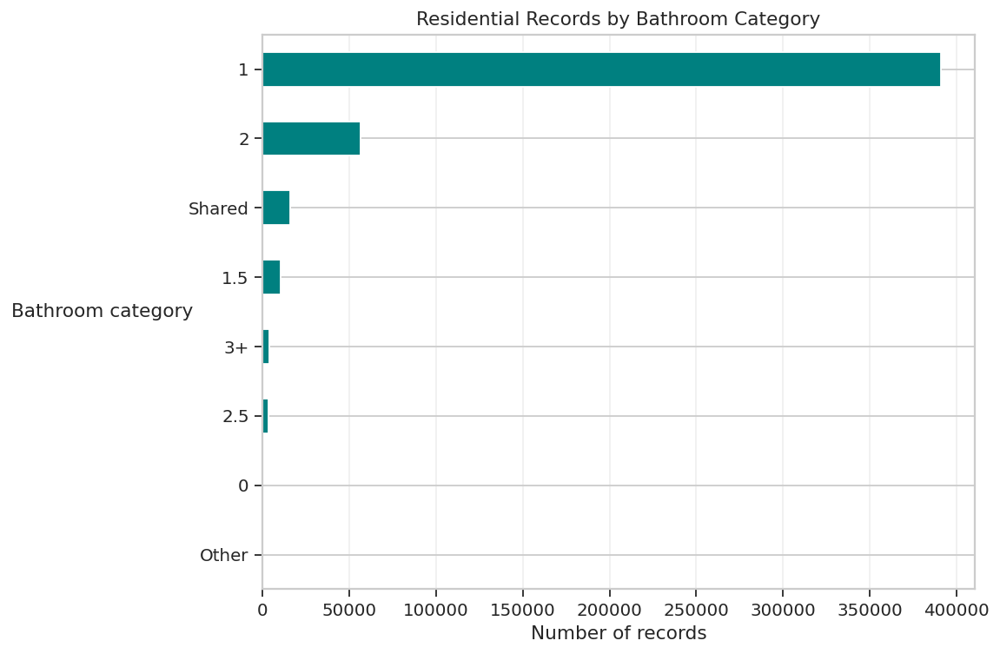

In [81]:
bathroom_counts = (
    eda["bathroom_count"]
    .dropna()
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 6))
bathroom_counts.plot(kind="barh", color="teal")
plt.xlabel("Number of records")
plt.ylabel("Bathroom category", rotation=0, labelpad=55, va="center")
plt.title("Residential Records by Bathroom Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Bivariate analysis

Bivariate analysis examines how rent changes across housing characteristics and neighborhoods.


## Visualization 4 — Rent by bedroom category

**Question:** Does rent vary across bedroom categories?


**Interpretation:** Compare the median line and the spread of each bedroom group. A higher median suggests a descriptive rent difference, while overlapping boxes show that bedroom count alone does not explain every rent value.


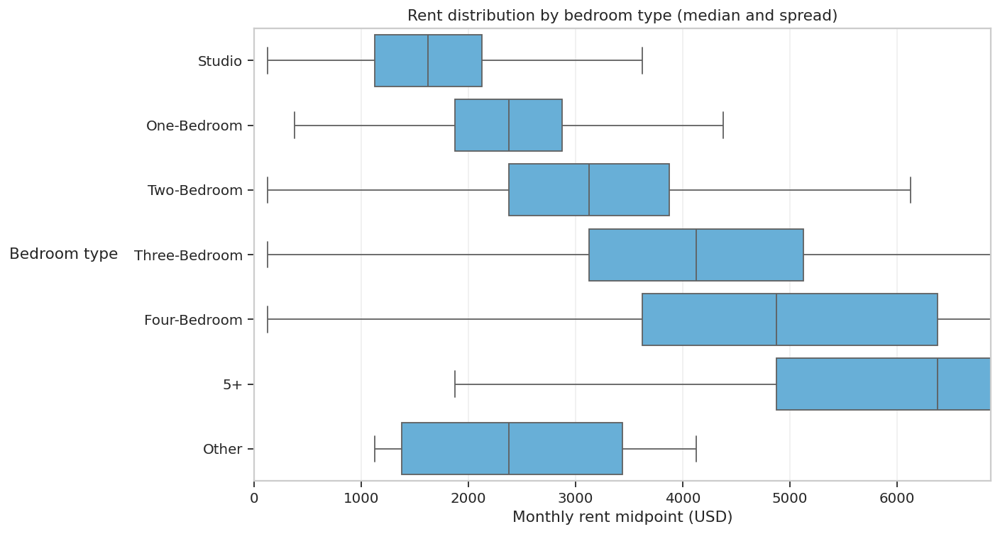

               record_count  median_rent    mean_rent
bedroom_count                                        
Studio               129214       1625.5  1657.334449
One-Bedroom          196571       2375.5  2418.494239
Two-Bedroom          119774       3125.5  3205.749537
Three-Bedroom         27995       4125.5  4067.800947
Four-Bedroom           5736       4875.5  4741.687326
5+                     1352       6375.5   5594.70895
Other                    24       2375.5  2427.583333

In [85]:
bedroom_order = ["0", "Studio", "One-Bedroom", "Two-Bedroom", "Three-Bedroom", "Four-Bedroom", "5+", "Other"]
available_bedrooms = [x for x in bedroom_order if x in eda["bedroom_count"].dropna().unique()]
box_data = eda[eda["bedroom_count"].isin(available_bedrooms)].copy()
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=box_data, x=target, y="bedroom_count", order=available_bedrooms, showfliers=False, color="#56B4E9", ax=ax)
ax.set_xlim(0, box_data[target].quantile(0.99)); ax.set_xlabel("Monthly rent midpoint (USD)"); ax.set_ylabel("Bedroom type", rotation=0, labelpad=55, va="center")
ax.set_title("Rent distribution by bedroom type (median and spread)"); ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()
bedroom_rent_summary = box_data.groupby("bedroom_count", observed=False)[target].agg(record_count="count", median_rent="median", mean_rent="mean").reindex(available_bedrooms)
display(bedroom_rent_summary)


## Visualization 5 — Rent and square footage

**Question:** Do larger units generally have higher monthly rent?**


**Interpretation:** The upward pattern indicates whether larger units tend to have higher rent. The vertical spread at similar sizes shows remaining variation, so correlation does not imply a fixed price rule or causation.


Pearson correlation: 0.626


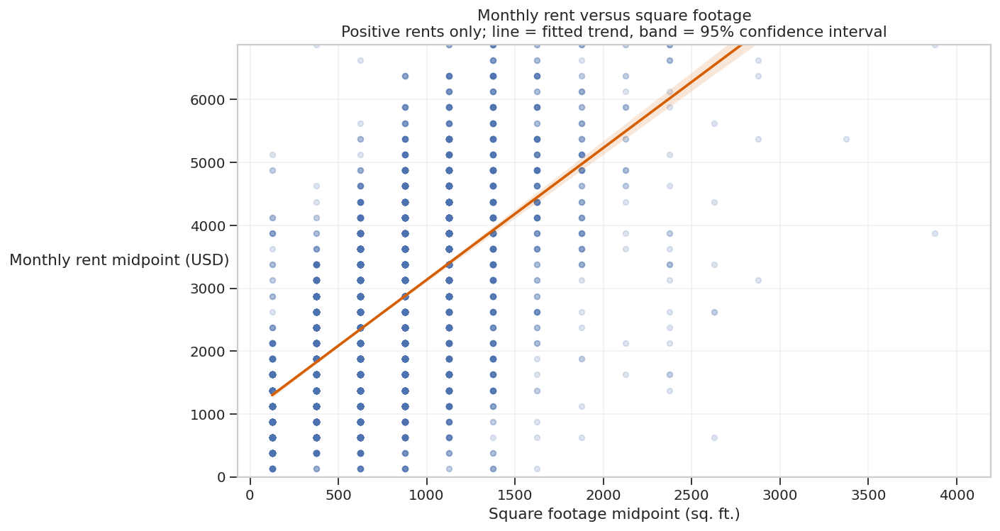

In [88]:
# Regression scatter plot: points show observations, line shows the fitted linear trend, and the band is a 95% confidence interval.
scatter_data = eda[["square_footage_midpoint", target]].dropna().copy()
scatter_sample = scatter_data.sample(n=min(10000, len(scatter_data)), random_state=42)
fig, ax = plt.subplots(figsize=(11, 6))
sns.regplot(data=scatter_sample, x="square_footage_midpoint", y=target,
            scatter_kws={"alpha": 0.18, "s": 18}, line_kws={"color": "#D55E00", "linewidth": 2}, ax=ax)
ax.set_ylim(bottom=0, top=scatter_data[target].quantile(.99))
ax.set_xlabel("Square footage midpoint (sq. ft.)")
ax.set_ylabel("Monthly rent midpoint (USD)", rotation=0, labelpad=55, va="center")
ax.set_title("Monthly rent versus square footage\nPositive rents only; line = fitted trend, band = 95% confidence interval")
ax.grid(alpha=.25); ax.tick_params(axis="both", which="major", length=6, width=1)
plt.tight_layout(); plt.show()
print("Pearson correlation:", round(scatter_data.corr().iloc[0, 1], 3))


## Visualization 6 — Neighborhood rent differences

**Question:** Does typical monthly rent differ across neighborhoods?**


**Interpretation:** Neighborhood medians are shown only for groups meeting the minimum record-count rule. This makes the comparison more stable, but the result still reflects neighborhood composition and should not be interpreted causally.


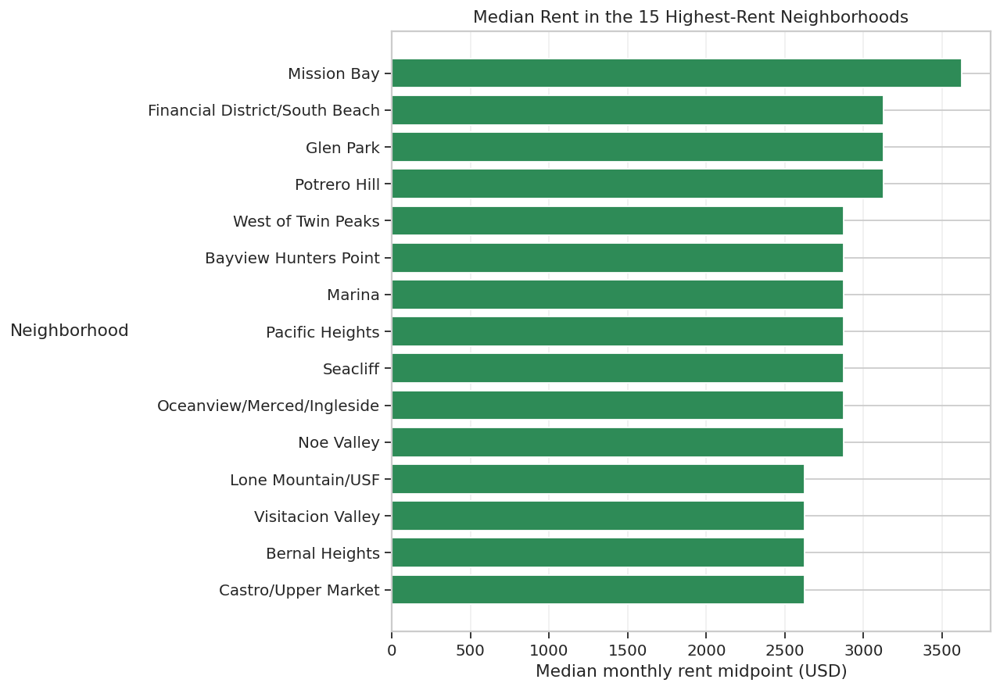

                                record_count  median_rent
analysis_neighborhood                                    
Mission Bay                            12999       3625.5
Financial District/South Beach         21789       3125.5
Potrero Hill                            7739       3125.5
Glen Park                               1036       3125.5
Seacliff                                 369       2875.5
Oceanview/Merced/Ingleside              1850       2875.5
Noe Valley                              9108       2875.5
West of Twin Peaks                      3077       2875.5
Bayview Hunters Point                   4308       2875.5
Marina                                 29048       2875.5
Pacific Heights                        28745       2875.5
Lone Mountain/USF                       8293       2625.5
Castro/Upper Market                    15783       2625.5
Bernal Heights                          3707       2625.5
Visitacion Valley                        463       2625.5

In [91]:
neighborhood_summary = (
    eda.dropna(subset=["analysis_neighborhood"])
    .groupby("analysis_neighborhood")[target]
    .agg(record_count="count", median_rent="median")
    .query("record_count >= 100")
    .sort_values("median_rent")
    .tail(15)
)

plt.figure(figsize=(10, 7))
plt.barh(neighborhood_summary.index, neighborhood_summary["median_rent"], color="seagreen")
plt.xlabel("Median monthly rent midpoint (USD)")
plt.ylabel("Neighborhood", rotation=0, labelpad=55, va="center")
plt.title("Median Rent in the 15 Highest-Rent Neighborhoods")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
display(neighborhood_summary.sort_values("median_rent", ascending=False))


## Visualization 7 — Rent by occupancy type

**Question:** Does the typical rent differ between occupied-by-non-owner and vacant records?**


**Interpretation:** Compare typical rent and spread across occupancy types. Differences may reflect the kind of units represented in each group, not an effect caused by occupancy status.


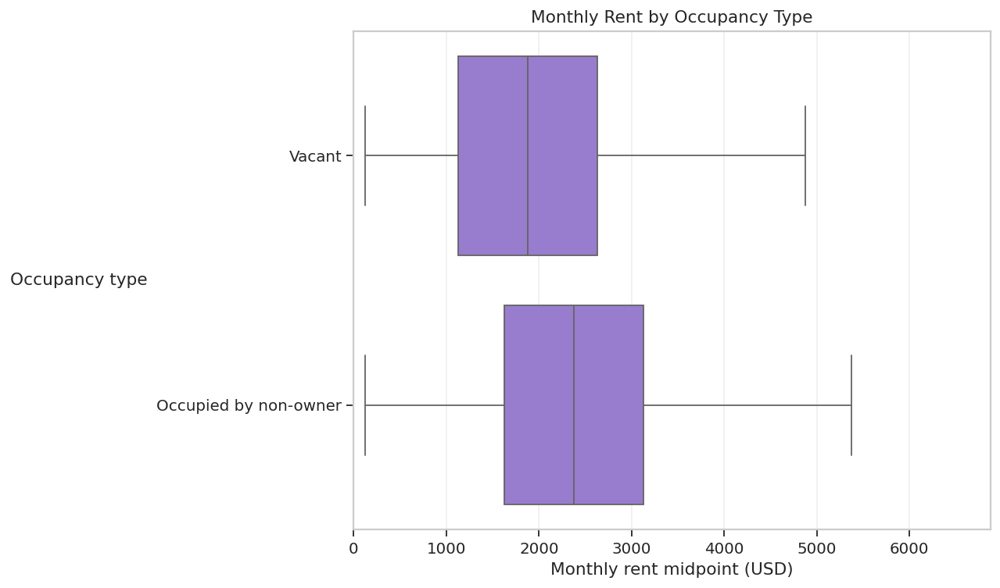

In [94]:
occupancy_rent_data = eda.dropna(subset=["occupancy_type", target]).copy()
occupancy_order = occupancy_rent_data.groupby("occupancy_type")[target].median().sort_values().index.tolist()

plt.figure(figsize=(10, 6))
sns.boxplot(data=occupancy_rent_data, x=target, y="occupancy_type", order=occupancy_order, showfliers=False, color="mediumpurple")
plt.xlim(0, occupancy_rent_data[target].quantile(0.99))
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Occupancy type", rotation=0, labelpad=55, va="center")
plt.title("Monthly Rent by Occupancy Type")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Rent over submission year

**Question:** Did typical positive rent change across submission years, and does the pattern differ by occupancy type?

The first graph shows the overall median and middle 50% rent range by submission year. The second separates occupancy types so an overall trend is not confused with a change in the mix of occupied and vacant records. Record counts are displayed in the supporting table. If only one submission year exists, a time trend cannot be interpreted.


   submission_year  record_count  median_rent  q1_rent  q3_rent
0             2022         57440       2125.5   1375.5   2875.5
1             2023         93019       2375.5   1625.5   3125.5
2             2024         95507       2375.5   1625.5   3125.5
3             2025        115901       2375.5   1625.5   3375.5
4             2026        119580       2625.5   1625.5   3375.5

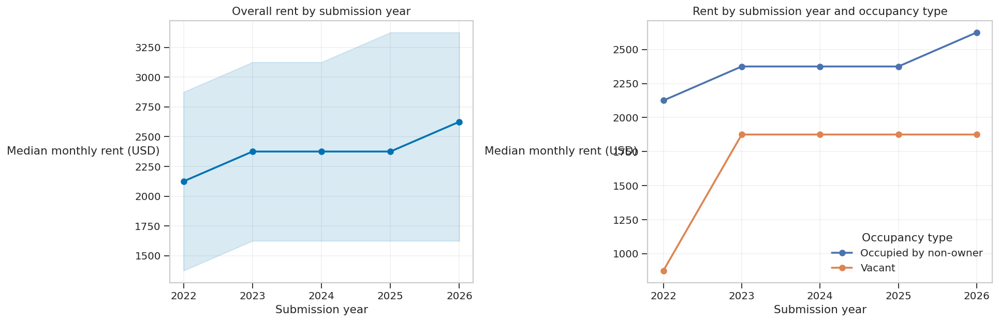

In [96]:
year_rent_data = eda[["submission_year", target, "occupancy_type"]].dropna().copy() if "submission_year" in eda.columns else pd.DataFrame()
if year_rent_data.empty:
    print("Submission-year rent analysis skipped: submission_year is unavailable or has no complete positive-rent records.")
else:
    year_rent_data["submission_year"] = pd.to_numeric(year_rent_data["submission_year"], errors="coerce")
    year_rent_data = year_rent_data.dropna(subset=["submission_year"])
    year_summary = year_rent_data.groupby("submission_year")[target].agg(record_count="count", median_rent="median", q1_rent=lambda x: x.quantile(.25), q3_rent=lambda x: x.quantile(.75)).reset_index()
    display(year_summary)
    if year_summary["submission_year"].nunique() < 2:
        print("Only one submission year is present, so a year-over-year rent trend cannot be interpreted.")
    else:
        from matplotlib.ticker import MaxNLocator, StrMethodFormatter
        fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.1, 1.25]})
        axes[0].plot(year_summary["submission_year"], year_summary["median_rent"], marker="o", color="#0072B2", linewidth=2)
        axes[0].fill_between(year_summary["submission_year"], year_summary["q1_rent"], year_summary["q3_rent"], color="#0072B2", alpha=.15)
        axes[0].set_title("Overall rent by submission year"); axes[0].set_xlabel("Submission year"); axes[0].set_ylabel("Median monthly rent (USD)", rotation=0, labelpad=55, va="center")
        axes[0].xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True)); axes[0].xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}")); axes[0].grid(alpha=.25)
        for occupancy, group in year_rent_data.groupby("occupancy_type"):
            grouped = group.groupby("submission_year")[target].agg(median="median", count="count").reset_index()
            if grouped["count"].sum() >= 30:
                axes[1].plot(grouped["submission_year"], grouped["median"], marker="o", linewidth=2, label=occupancy)
        axes[1].set_title("Rent by submission year and occupancy type"); axes[1].set_xlabel("Submission year"); axes[1].set_ylabel("Median monthly rent (USD)", rotation=0, labelpad=55, va="center")
        axes[1].xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True)); axes[1].xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}")); axes[1].grid(alpha=.25); axes[1].legend(title="Occupancy type", frameon=False)
        for ax in axes: ax.tick_params(axis="both", which="major", length=6, width=1)
        plt.tight_layout(); plt.show()


## Visualization 8 — Rent by property-age group

**Question:** Does typical rent vary by property age?**


**Interpretation:** Age groups help reveal whether newer or older properties have different rent distributions. Overlapping boxes indicate that property age is only one part of the rent pattern.


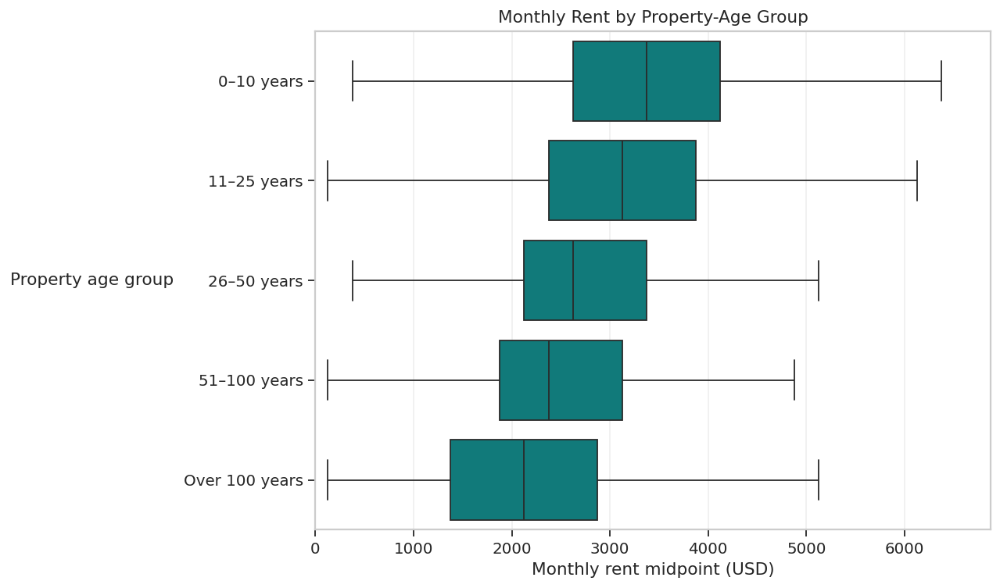

In [99]:
age_plot_data = eda.dropna(subset=["property_age", target]).copy()
age_bins = [-1, 10, 25, 50, 100, 300]
age_labels = ["0–10 years", "11–25 years", "26–50 years", "51–100 years", "Over 100 years"]
age_plot_data["property_age_group"] = pd.cut(age_plot_data["property_age"], bins=age_bins, labels=age_labels)

plt.figure(figsize=(10, 6))
sns.boxplot(data=age_plot_data, x=target, y="property_age_group", order=age_labels, showfliers=False, color="darkcyan")
plt.xlim(0, age_plot_data[target].quantile(0.99))
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Property age group", rotation=0, labelpad=65, va="center")
plt.title("Monthly Rent by Property-Age Group")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization 9 — Missingness relevant to EDA

**Question:** Which analysis features still have missing values, and where is imputation potentially needed?**


**Interpretation:** The missingness chart identifies which variables may reduce the usable sample for a particular plot. These observed-data percentages guide later imputation decisions but are not evidence that missing values are random.


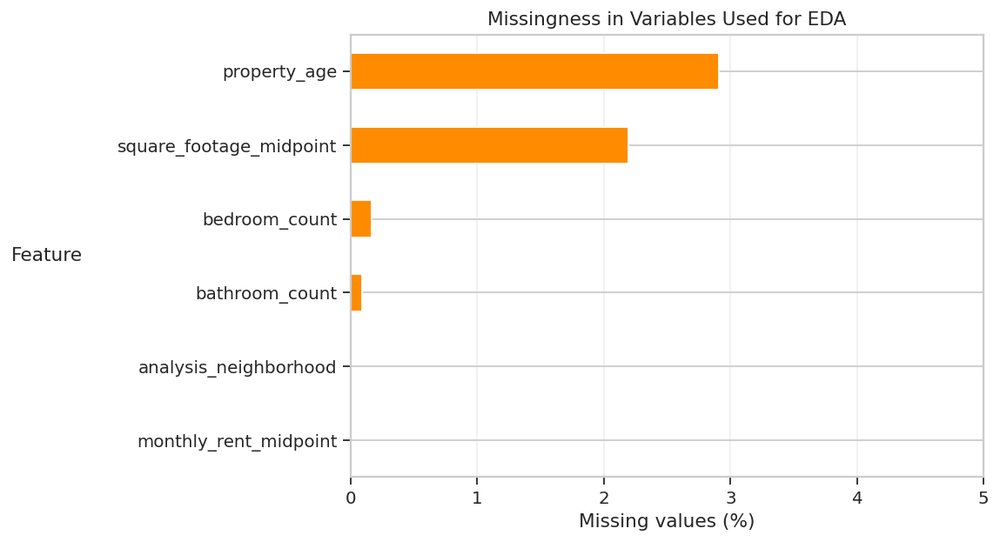

                         missing_percentage
monthly_rent_midpoint              0.000000
analysis_neighborhood              0.002700
bathroom_count                     0.092222
bedroom_count                      0.162219
square_footage_midpoint            2.192142
property_age                       2.910808

In [102]:
feature_missing = (
    eda[[target, "square_footage_midpoint", "property_age", "bedroom_count", "bathroom_count", "analysis_neighborhood"]]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 5))
feature_missing.plot(kind="barh", color="darkorange")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature", rotation=0, labelpad=45, va="center")
plt.title("Missingness in Variables Used for EDA")
plt.xlim(0, max(5, feature_missing.max() * 1.15))
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
display(feature_missing.to_frame("missing_percentage"))


## Multivariate analysis

Multivariate analysis examines several numeric variables together to identify overlapping relationships with rent.


## Visualization 10 — Numeric association with rent

**Question:** Which numeric housing characteristics have the strongest linear association with monthly rent?


**Interpretation:** Correlations describe pairwise linear association among numeric representations of the variables. Bedroom and bathroom categories were mapped to numeric equivalents only for this summary; this is not a causal model.


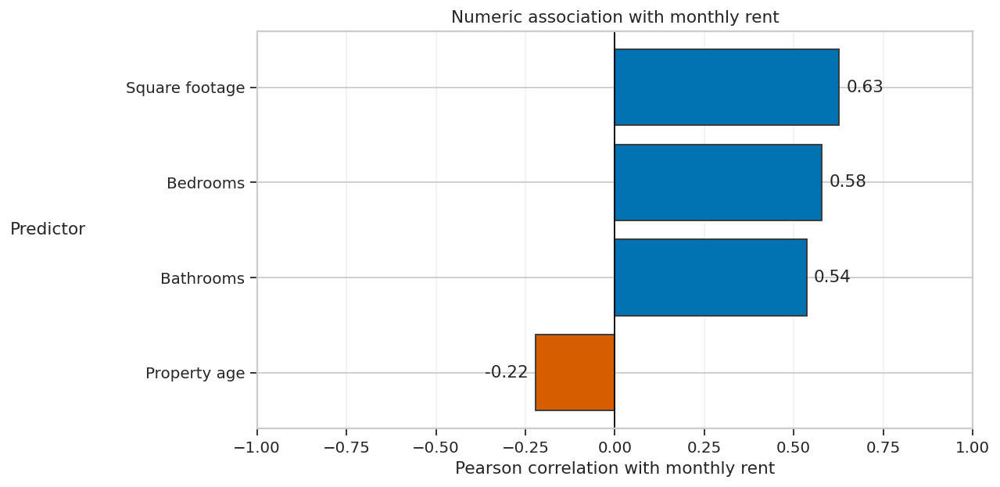

                Correlation with rent
Property age                -0.221093
Bathrooms                    0.536331
Bedrooms                     0.578898
Square footage               0.626317

In [106]:
# Direct, readable correlation summary: show each numeric relationship with rent.
# A horizontal bar chart is used instead of a dense heatmap because the goal is to compare predictors with the target.
bedroom_numeric_map = {"0": 0, "Studio": 0, "One-Bedroom": 1, "Two-Bedroom": 2, "Three-Bedroom": 3, "Four-Bedroom": 4, "5+": 5}
bathroom_numeric_map = {"1": 1.0, "1.5": 1.5, "2": 2.0, "2.5": 2.5, "3+": 3.0}
corr_data = pd.DataFrame(index=eda.index)
corr_data["Rent"] = pd.to_numeric(eda[target], errors="coerce")
if "square_footage_midpoint" in eda.columns:
    corr_data["Square footage"] = pd.to_numeric(eda["square_footage_midpoint"], errors="coerce")
if "property_age" in eda.columns:
    corr_data["Property age"] = pd.to_numeric(eda["property_age"], errors="coerce")
if "bedroom_count" in eda.columns:
    corr_data["Bedrooms"] = eda["bedroom_count"].map(bedroom_numeric_map)
if "bathroom_count" in eda.columns:
    corr_data["Bathrooms"] = eda["bathroom_count"].map(bathroom_numeric_map)
corr_data = corr_data.apply(pd.to_numeric, errors="coerce")
corr_with_rent = corr_data.corr(min_periods=2)["Rent"].drop("Rent", errors="ignore").dropna().sort_values()

if corr_with_rent.empty:
    print("Correlation plot skipped: no predictors had enough numeric observations.")
else:
    colors = ["#D55E00" if value < 0 else "#0072B2" for value in corr_with_rent]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(corr_with_rent.index, corr_with_rent.values, color=colors, edgecolor="#333333")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlim(-1, 1)
    ax.set_xlabel("Pearson correlation with monthly rent")
    ax.set_ylabel("Predictor", rotation=0, labelpad=55, va="center")
    ax.set_title("Numeric association with monthly rent")
    ax.grid(axis="x", alpha=.25)
    for bar, value in zip(bars, corr_with_rent.values):
        offset = .02 if value >= 0 else -.02
        ax.text(value + offset, bar.get_y() + bar.get_height()/2, f"{value:.2f}", va="center", ha="left" if value >= 0 else "right")
    plt.tight_layout(); plt.show()
    display(corr_with_rent.to_frame("Correlation with rent"))


## Cleaning validation visualizations

These figures show the effect of validation and target filtering before interpreting the cleaned data.


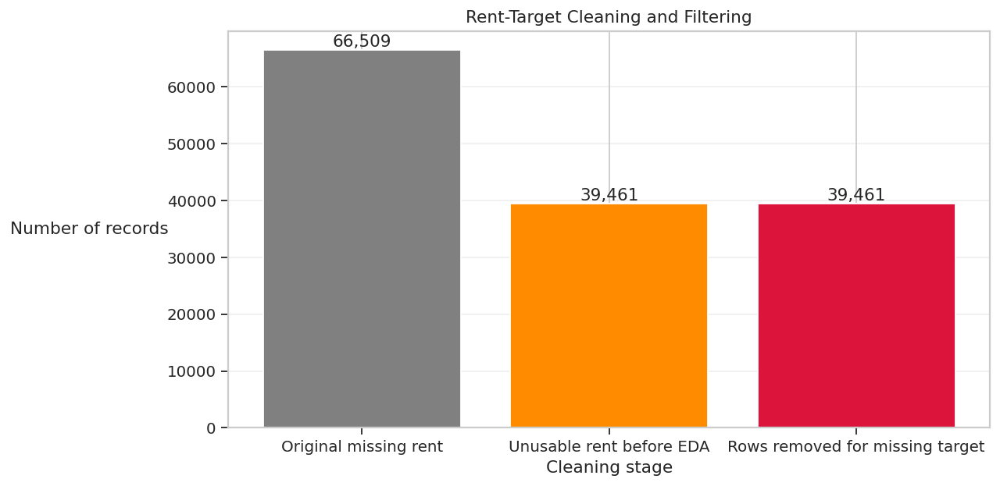

In [108]:
cleaning_stage_plot = pd.DataFrame({
    "stage": ["Original missing rent", "Unusable rent before EDA", "Rows removed for missing target"],
    "records": [
        int(df["monthly_rent"].isna().sum()),
        int(cleaned["monthly_rent_midpoint"].isna().sum()),
        int(rows_removed_for_target),
    ],
})

plt.figure(figsize=(10, 5))
bars = plt.bar(cleaning_stage_plot["stage"], cleaning_stage_plot["records"], color=["gray", "darkorange", "crimson"])
plt.xlabel("Cleaning stage")
plt.ylabel("Number of records", rotation=0, labelpad=55, va="center")
plt.title("Rent-Target Cleaning and Filtering")
plt.xticks(rotation=0, ha="center")
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(bar.get_height()):,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


### Bedroom standardization check

**Question:** How did the bedroom categories change from the original labels to the cleaned labels used in EDA?


**Interpretation:** Gray bars show original labels and blue bars show the consolidated labels used for analysis. The comparison confirms whether inconsistent labels were combined without losing the record totals.


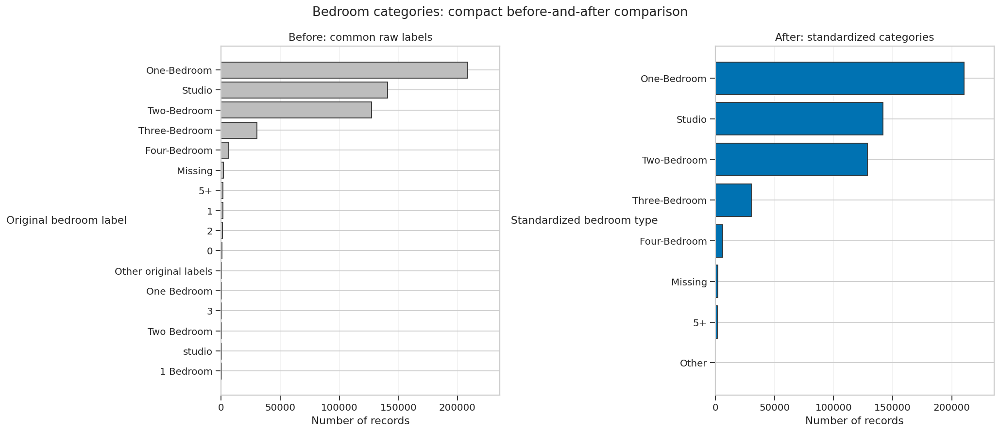

In [111]:
# Side-by-side comparison showing common raw labels before cleaning.
raw_bedroom_counts = cleaned["bedroom_count_before_standardization"].astype("string").str.strip().replace("", pd.NA).fillna("Missing").value_counts()
raw_bedroom_top = raw_bedroom_counts.nlargest(15).sort_values()
raw_bedroom_remainder = raw_bedroom_counts.drop(raw_bedroom_top.index).sum()
if raw_bedroom_remainder > 0:
    raw_bedroom_top["Other original labels"] = raw_bedroom_remainder
raw_bedroom_top = raw_bedroom_top.sort_values()
clean_bedroom_counts = cleaned["bedroom_count"].fillna("Missing").value_counts().sort_values()
max_bedroom_count = max(raw_bedroom_top.max(), clean_bedroom_counts.max())
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
axes[0].barh(raw_bedroom_top.index, raw_bedroom_top.values, color="#BDBDBD", edgecolor="#333333")
axes[0].set_title("Before: common raw labels")
axes[0].set_ylabel("Original bedroom label", rotation=0, labelpad=55, va="center")
axes[1].barh(clean_bedroom_counts.index, clean_bedroom_counts.values, color="#0072B2", edgecolor="#333333")
axes[1].set_title("After: standardized categories")
axes[1].set_ylabel("Standardized bedroom type", rotation=0, labelpad=55, va="center")
for ax in axes:
    ax.set_xlim(0, max_bedroom_count * 1.12)
    ax.set_xlabel("Number of records")
    ax.grid(axis="x", alpha=.25)
    ax.tick_params(axis="both", which="major", length=6, width=1)
fig.suptitle("Bedroom categories: compact before-and-after comparison")
plt.tight_layout(); plt.show()


### Bathroom standardization check

**Question:** Which bathroom labels were consolidated before the rent analysis?


**Interpretation:** Gray bars show original bathroom labels and green bars show standardized categories. Retained Shared, Other, and Missing groups should remain visible because they carry different meanings.


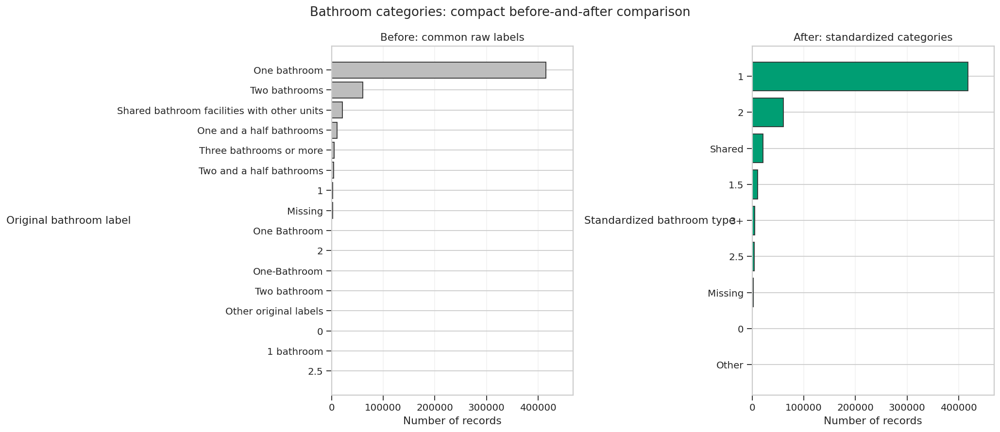

In [114]:
# Side-by-side comparison showing common raw labels before cleaning.
raw_bathroom_counts = cleaned["bathroom_count_before_standardization"].astype("string").str.strip().replace("", pd.NA).fillna("Missing").value_counts()
raw_bathroom_top = raw_bathroom_counts.nlargest(15).sort_values()
raw_bathroom_remainder = raw_bathroom_counts.drop(raw_bathroom_top.index).sum()
if raw_bathroom_remainder > 0:
    raw_bathroom_top["Other original labels"] = raw_bathroom_remainder
raw_bathroom_top = raw_bathroom_top.sort_values()
clean_bathroom_counts = cleaned["bathroom_count"].fillna("Missing").value_counts().sort_values()
max_bathroom_count = max(raw_bathroom_top.max(), clean_bathroom_counts.max())
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
axes[0].barh(raw_bathroom_top.index, raw_bathroom_top.values, color="#BDBDBD", edgecolor="#333333")
axes[0].set_title("Before: common raw labels")
axes[0].set_ylabel("Original bathroom label", rotation=0, labelpad=55, va="center")
axes[1].barh(clean_bathroom_counts.index, clean_bathroom_counts.values, color="#009E73", edgecolor="#333333")
axes[1].set_title("After: standardized categories")
axes[1].set_ylabel("Standardized bathroom type", rotation=0, labelpad=55, va="center")
for ax in axes:
    ax.set_xlim(0, max_bathroom_count * 1.12)
    ax.set_xlabel("Number of records")
    ax.grid(axis="x", alpha=.25)
    ax.tick_params(axis="both", which="major", length=6, width=1)
fig.suptitle("Bathroom categories: compact before-and-after comparison")
plt.tight_layout(); plt.show()


## Univariate analysis — continued

These distributions examine important numeric features beyond the rent target.


## Visualization 11 — Square-footage distribution

**Question:** What is the distribution and spread of housing size?**


**Interpretation:** The square-footage distribution shows the typical unit size and its right tail. The 99th-percentile cap improves readability, while the reported median summarizes the untrimmed valid values.


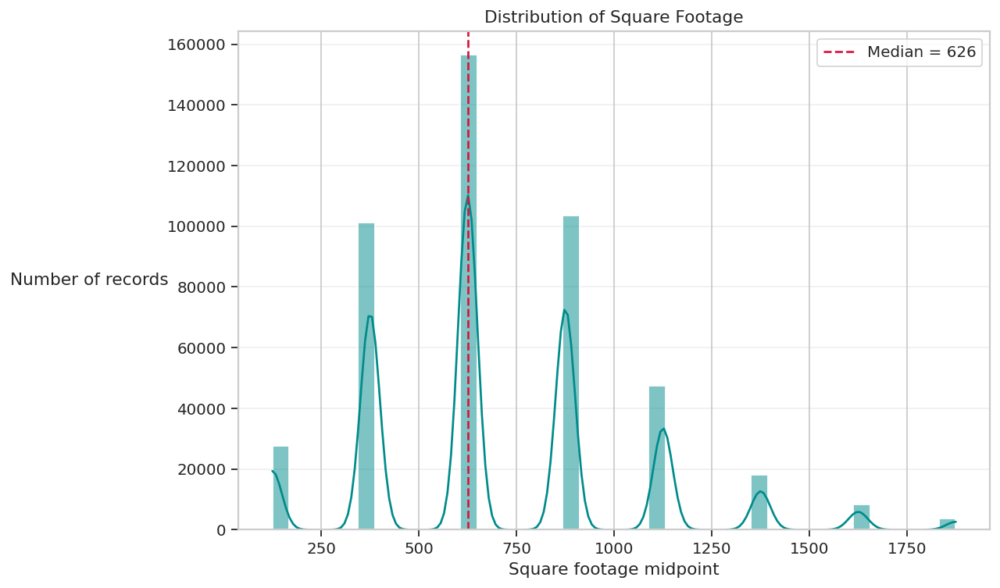

In [118]:
sqft_values = eda["square_footage_midpoint"].dropna()
sqft_cap = sqft_values.quantile(0.99)
plt.figure(figsize=(10, 6))
sns.histplot(sqft_values[sqft_values <= sqft_cap], bins=40, kde=True, color="darkcyan")
plt.axvline(sqft_values.median(), color="crimson", linestyle="--", label=f"Median = {sqft_values.median():,.0f}")
plt.xlabel("Square footage midpoint")
plt.ylabel("Number of records", rotation=0, labelpad=55, va="center")
plt.title("Distribution of Square Footage")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization 12 — Property-age distribution

**Question:** How old are the properties in the analysis dataset?**


**Interpretation:** The property-age distribution shows whether the dataset is concentrated in newer or older buildings. Extreme ages were treated as missing during validation rather than silently retained.


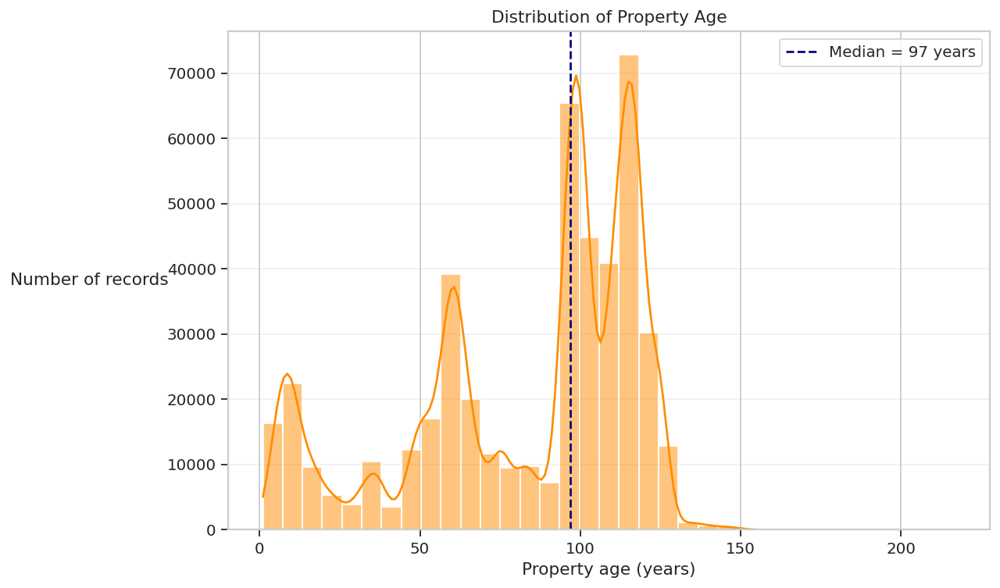

In [121]:
age_values = eda["property_age"].dropna()
plt.figure(figsize=(10, 6))
sns.histplot(age_values, bins=35, kde=True, color="darkorange")
plt.axvline(age_values.median(), color="navy", linestyle="--", label=f"Median = {age_values.median():,.0f} years")
plt.xlabel("Property age (years)")
plt.ylabel("Number of records", rotation=0, labelpad=55, va="center")
plt.title("Distribution of Property Age")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Bivariate analysis — continued

These plots test additional relationships between rent and housing characteristics.


## Visualization 13 — Rent by bathroom category

**Question:** Does rent vary across bathroom categories?**


**Interpretation:** Compare median rent and spread across bathroom categories. Differences should be read with category counts in mind, especially for 3+, Shared, Other, or rare groups.


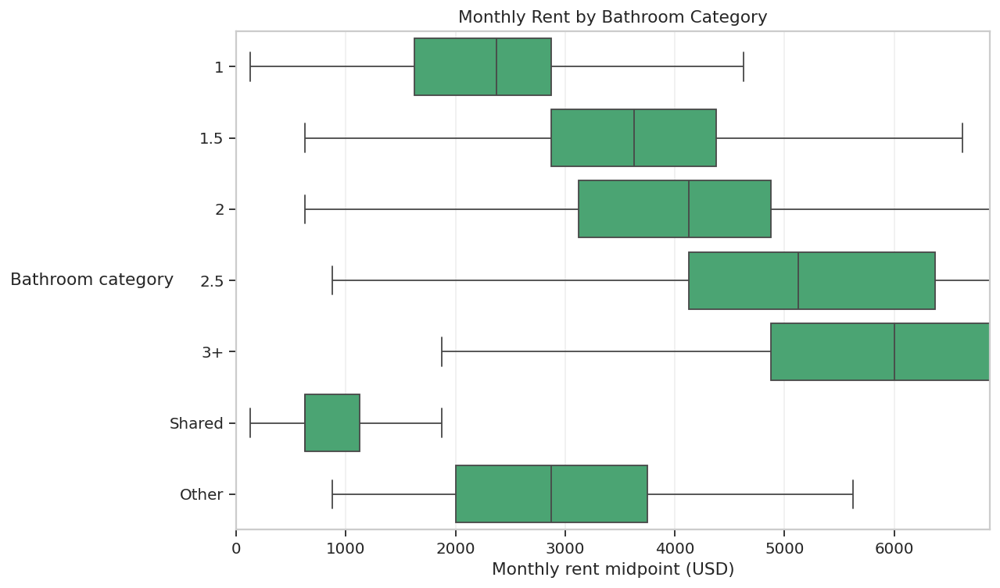

In [125]:
bathroom_order = ["1", "1.5", "2", "2.5", "3+", "Shared", "Other"]
available_bathrooms = [x for x in bathroom_order if x in eda["bathroom_count"].dropna().unique()]
bathroom_box_data = eda[eda["bathroom_count"].isin(available_bathrooms)].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=bathroom_box_data, x=target, y="bathroom_count", order=available_bathrooms, showfliers=False, color="mediumseagreen")
plt.xlim(0, bathroom_box_data[target].quantile(0.99))
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Bathroom category", rotation=0, labelpad=55, va="center")
plt.title("Monthly Rent by Bathroom Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization 14 — Rent versus property age

**Question:** Is property age associated with monthly rent?**


**Interpretation:** The plot tests whether rent changes systematically with property age. A weak or diffuse pattern means age has limited standalone explanatory power even if a trend line appears.


Pearson correlation: -0.221


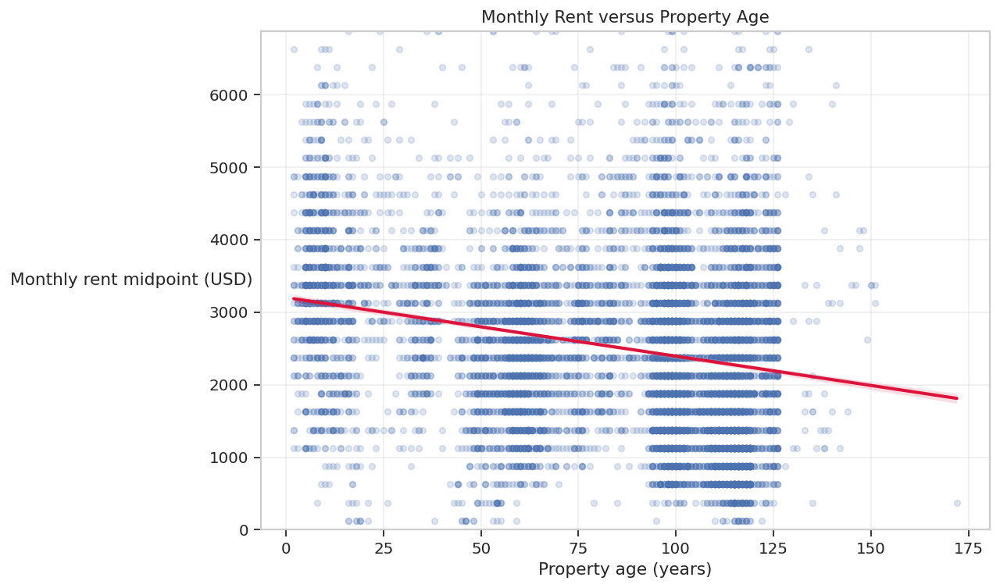

In [128]:
age_rent_data = eda[["property_age", target]].dropna().copy()
age_rent_sample = age_rent_data.sample(n=min(10000, len(age_rent_data)), random_state=42)
plt.figure(figsize=(10, 6))
sns.regplot(data=age_rent_sample, x="property_age", y=target, scatter_kws={"alpha": 0.18, "s": 18}, line_kws={"color": "crimson"})
plt.ylim(0, age_rent_data[target].quantile(0.99))
plt.xlabel("Property age (years)")
plt.ylabel("Monthly rent midpoint (USD)", rotation=0, labelpad=55, va="center")
plt.title("Monthly Rent versus Property Age")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Pearson correlation:", round(age_rent_data.corr().iloc[0, 1], 3))


## Visualization 15 — Rent by included utility

**Question:** Do median rents differ when utilities are included in the base rent?**


**Interpretation:** The bars compare median rent when each utility is included versus not included. These are descriptive differences and may reflect different unit types or neighborhoods; they do not establish that utilities cause rent changes.


Raw utility coding check:
Within-bedroom utility comparison:
Interpretation: a larger Not included group affects stability, but does not by itself make its median higher. The within-bedroom table checks whether bedroom composition explains part of the overall difference. Utility status remains an association, not a causal effect.


              Utility Utility status  median_rent  record_count  group_percentage
0         Electricity       Included       1375.5         30852              6.41
1         Electricity   Not included       2375.5        450595             93.59
2         Natural gas       Included       1875.5         51697             10.74
3         Natural gas   Not included       2375.5        429750             89.26
4  Refuse / recycling       Included       2125.5        287713             59.76
5  Refuse / recycling   Not included       2875.5        193734             40.24
6       Water / sewer       Included       2125.5        285445             59.29
7       Water / sewer   Not included       2625.5        196002             40.71

                                raw_record_count
base_rent_includes_water_sewer                  
Y                                         288333
N                                         263218

                                raw_record_count
base_rent_includes_natural_gas                  
N                                         499143
Y                                          52408

                                raw_record_count
base_rent_includes_electricity                  
N                                         520029
Y                                          31522

                                     raw_record_count
base_rent_includes_refuse_recycling                  
Y                                              290640
N                                              260911

                                                                raw_record_count
base_rent_includes_other_utilities                                              
NaN                                                                       512939
heat                                                                       16408
other                                                                      11119
steam heat                                                                  5678
wifi                                                                         623
parking                                                                      620
pest control                                                                 373
cable and internet                                                           319
internet                                                                     282
parking & heat                                                               219
yes                         

               Utility  bedroom_count Utility status  record_count  median_rent
0          Electricity             5+       Included            72       6875.5
1          Electricity             5+   Not included          1280       6375.5
2          Electricity   Four-Bedroom       Included           223       2875.5
3          Electricity   Four-Bedroom   Not included          5513       5125.5
4          Electricity    One-Bedroom       Included          8680       2125.5
5          Electricity    One-Bedroom   Not included        187891       2375.5
6          Electricity          Other   Not included            24       2375.5
7          Electricity         Studio       Included         16449       1125.5
8          Electricity         Studio   Not included        112765       1625.5
9          Electricity  Three-Bedroom       Included          1090       3625.5
10         Electricity  Three-Bedroom   Not included         26905       4125.5
11         Electricity    Two-Bedroom   

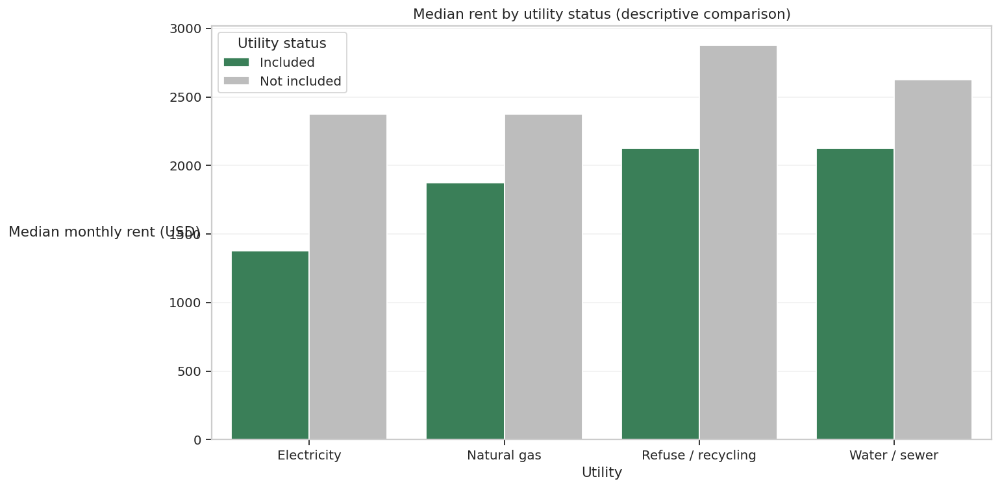

In [131]:
# Utility comparison with record counts and a cautious interpretation.
utility_labels = {
    "base_rent_includes_water_sewer": "Water / sewer",
    "base_rent_includes_natural_gas": "Natural gas",
    "base_rent_includes_electricity": "Electricity",
    "base_rent_includes_refuse_recycling": "Refuse / recycling",
    "base_rent_includes_other_utilities": "Other utilities",
}
utility_rows = []
for col, label in utility_labels.items():
    if col in eda.columns:
        temp = eda[[col, target]].dropna().copy()
        temp["Utility"] = label
        temp["Utility status"] = temp[col].map({1: "Included", 0: "Not included"}).fillna("Missing")
        utility_rows.append(temp[["Utility", "Utility status", target]])
if utility_rows:
    utility_plot_data = pd.concat(utility_rows, ignore_index=True)
    utility_summary = utility_plot_data.groupby(["Utility", "Utility status"])[target].agg(median_rent="median", record_count="count").reset_index()
    utility_summary["group_percentage"] = utility_summary.groupby("Utility")["record_count"].transform(lambda x: x / x.sum() * 100).round(2)
    display(utility_summary)
    print("Raw utility coding check:")
    for col, label in utility_labels.items():
        if col in df.columns:
            display(df[col].value_counts(dropna=False).rename(label).to_frame("raw_record_count"))

    # Check whether the overall difference is explained by bedroom composition.
    bedroom_utility_rows = []
    for col, label in utility_labels.items():
        if col in eda.columns and "bedroom_count" in eda.columns:
            temp = eda[["bedroom_count", col, target]].dropna().copy()
            temp["Utility"] = label
            temp["Utility status"] = temp[col].map({1: "Included", 0: "Not included"})
            bedroom_utility_rows.append(temp[["bedroom_count", "Utility", "Utility status", target]])
    if bedroom_utility_rows:
        within_bedroom = pd.concat(bedroom_utility_rows, ignore_index=True).groupby(["Utility", "bedroom_count", "Utility status"])[target].agg(record_count="count", median_rent="median").reset_index()
        print("Within-bedroom utility comparison:")
        display(within_bedroom.sort_values(["Utility", "bedroom_count", "Utility status"]))
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=utility_summary, x="Utility", y="median_rent", hue="Utility status", palette={"Included": "#2E8B57", "Not included": "#BDBDBD", "Missing": "#D55E00"}, ax=ax)
    ax.set_xlabel("Utility"); ax.set_ylabel("Median monthly rent (USD)", rotation=0, labelpad=55, va="center")
    ax.set_title("Median rent by utility status (descriptive comparison)")
    ax.tick_params(axis="x", rotation=0); ax.grid(axis="y", alpha=.25)
    plt.tight_layout(); plt.show()
    print("Interpretation: a larger Not included group affects stability, but does not by itself make its median higher. The within-bedroom table checks whether bedroom composition explains part of the overall difference. Utility status remains an association, not a causal effect.")
else:
    print("Utility analysis skipped: no utility columns are available.")


## Multivariate analysis — continued

These plots examine combinations of features rather than one relationship at a time.


## Visualization 16 — Bedroom and bathroom rent comparison

**Question:** How does median rent change across bedroom–bathroom combinations, and which combinations have enough records to interpret?


**Interpretation:** The left panel compares typical rent for each bedroom–bathroom combination, while the right panel shows how many records support that comparison. A high median with very few records is descriptive only; larger, well-supported combinations provide the stronger comparison.


The left panel compares median rent; the right panel shows record counts so sparse combinations are not over-interpreted.


    Bedrooms  Bathrooms  median_rent  record_count
0        0.0        1.0       1625.5        115585
1        0.0        1.5       3125.5            54
2        0.0        2.0       3125.5           113
3        0.0        3.0       3125.5            36
4        1.0        1.0       2375.5        191076
5        1.0        1.5       3375.5          1815
6        1.0        2.0       3625.5          1288
7        1.0        2.5       3750.5            32
8        1.0        3.0       3875.5             4
9        2.0        1.0       2875.5         74113
10       2.0        1.5       3375.5          5001
11       2.0        2.0       3875.5         39135
12       2.0        2.5       4625.5          1231
13       2.0        3.0       5375.5           205
14       3.0        1.0       3375.5          8973
15       3.0        1.5       3875.5          2693
16       3.0        2.0       4375.5         12879
17       3.0        2.5       5375.5          1664
18       3.0        3.0       5

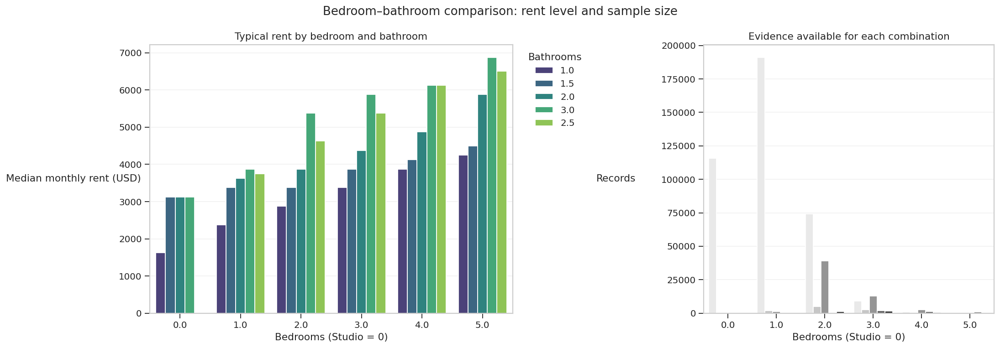

In [135]:
# Two-panel comparison: median rent and record count by bedroom-bathroom combination.
bedroom_numeric = eda["bedroom_count"].map({"0": 0, "Studio": 0, "One-Bedroom": 1, "Two-Bedroom": 2, "Three-Bedroom": 3, "Four-Bedroom": 4, "5+": 5})
bathroom_numeric = eda["bathroom_count"].map({"1": 1, "1.5": 1.5, "2": 2, "2.5": 2.5, "3+": 3})
combo = pd.DataFrame({"Bedrooms": bedroom_numeric, "Bathrooms": bathroom_numeric, target: eda[target]}).dropna()
combo_summary = combo.groupby(["Bedrooms", "Bathrooms"], as_index=False)[target].agg(median_rent="median", record_count="count")
if combo_summary.empty:
    print("Bedroom/bathroom comparison skipped: no complete combinations remain.")
else:
    display(combo_summary.sort_values(["Bedrooms", "Bathrooms"]))
    combo_summary["Bedrooms"] = combo_summary["Bedrooms"].astype(str)
    combo_summary["Bathrooms"] = combo_summary["Bathrooms"].astype(str)
    fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.25, 1]})
    sns.barplot(data=combo_summary, x="Bedrooms", y="median_rent", hue="Bathrooms", errorbar=None, palette="viridis", ax=axes[0])
    axes[0].set_xlabel("Bedrooms (Studio = 0)"); axes[0].set_ylabel("Median monthly rent (USD)", rotation=0, labelpad=55, va="center")
    axes[0].set_title("Typical rent by bedroom and bathroom")
    axes[0].legend(title="Bathrooms", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    axes[0].grid(axis="y", alpha=.25)
    sns.barplot(data=combo_summary, x="Bedrooms", y="record_count", hue="Bathrooms", errorbar=None, palette="Greys", ax=axes[1])
    axes[1].set_xlabel("Bedrooms (Studio = 0)"); axes[1].set_ylabel("Records", rotation=0, labelpad=55, va="center")
    axes[1].set_title("Evidence available for each combination")
    axes[1].legend_.remove()
    axes[1].grid(axis="y", alpha=.25)
    for ax in axes:
        ax.tick_params(axis="both", which="major", length=6, width=1)
    fig.suptitle("Bedroom–bathroom comparison: rent level and sample size")
    plt.tight_layout(); plt.show()
    print("The left panel compares median rent; the right panel shows record counts so sparse combinations are not over-interpreted.")


## Visualization 17 — Rent and square footage by occupancy type

**Question:** Does the rent–size relationship look similar across occupancy types?**


**Interpretation:** The lines compare median rent across similar square-footage ranges for each occupancy type. The shaded bands show the middle 50% of rents, making both the typical pattern and uncertainty visible without overplotting thousands of points.


Interpretation: lines compare typical rent at similar size ranges; shaded bands show the middle 50% of rents. This is more interpretable than a dense raw scatterplot.


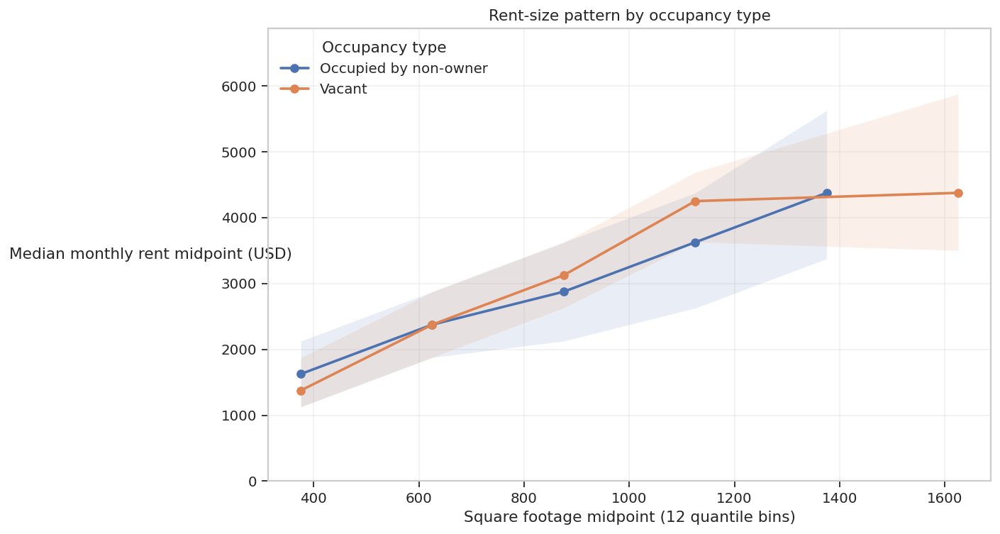

          occupancy_type  size_midpoint  median_rent  record_count
0  Occupied by non-owner          375.5       1625.5        127864
1  Occupied by non-owner          625.5       2375.5        156119
2  Occupied by non-owner          875.5       2875.5        103268
3  Occupied by non-owner         1125.5       3625.5         47474
4  Occupied by non-owner         1375.5       4375.5         34576
5                 Vacant          375.5       1375.5           947
6                 Vacant          625.5       2375.5           386
7                 Vacant          875.5       3125.5           191
8                 Vacant         1125.5       4250.5            44
9                 Vacant         1625.5       4375.5            24

In [138]:
# Compare occupancy types with binned median rent and an interquartile band.
facet_data = eda[["occupancy_type", "square_footage_midpoint", target]].dropna().copy()
if len(facet_data) < 10:
    print("Rent-size comparison skipped: not enough complete observations.")
else:
    facet_data["size_bin"] = pd.qcut(facet_data["square_footage_midpoint"], q=12, duplicates="drop")
    binned = facet_data.groupby(["occupancy_type", "size_bin"], observed=True).agg(
        size_midpoint=("square_footage_midpoint", "median"),
        median_rent=(target, "median"),
        q1_rent=(target, lambda x: x.quantile(.25)),
        q3_rent=(target, lambda x: x.quantile(.75)),
        record_count=(target, "count")
    ).reset_index()
    fig, ax = plt.subplots(figsize=(11, 6))
    for occupancy, group in binned.groupby("occupancy_type"):
        group = group.sort_values("size_midpoint")
        ax.plot(group["size_midpoint"], group["median_rent"], marker="o", linewidth=2, label=occupancy)
        ax.fill_between(group["size_midpoint"], group["q1_rent"], group["q3_rent"], alpha=.12)
    ax.set_xlabel("Square footage midpoint (12 quantile bins)")
    ax.set_ylabel("Median monthly rent midpoint (USD)", rotation=0, labelpad=55, va="center")
    ax.set_title("Rent-size pattern by occupancy type")
    ax.set_ylim(0, facet_data[target].quantile(.99))
    ax.legend(title="Occupancy type", frameon=False)
    ax.grid(alpha=.25); plt.tight_layout(); plt.show()
    display(binned[["occupancy_type", "size_midpoint", "median_rent", "record_count"]])
    print("Interpretation: lines compare typical rent at similar size ranges; shaded bands show the middle 50% of rents. This is more interpretable than a dense raw scatterplot.")


## Occupancy/vacancy date validation and analysis

**Question:** Are occupancy/vacancy dates valid, and what time pattern is visible after validation?

Dates are parsed with `errors="coerce"`; blank or invalid text becomes missing. Dates after the row's submission year or before 1800 are treated as domain-invalid. The plots use only valid dates and do not impute dates. The time trend is aggregated into five-year periods so the x-axis remains readable; each period bar is the total number of valid records whose date falls within that interval.


                   check      value
0                   Rows  520914.00
1   Missing/invalid text   72756.00
2   Domain-invalid dates     510.00
3            Valid dates  447648.00
4  Valid-date percentage      85.94

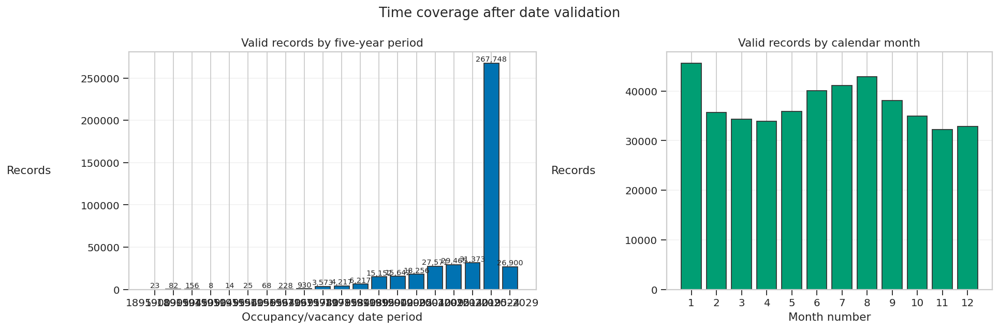

In [140]:
date_col = "occupancy_or_vacancy_date"
if date_col not in cleaned.columns:
    print("Date analysis skipped: occupancy/vacancy date is not present.")
else:
    parsed_dates = pd.to_datetime(cleaned[date_col], errors="coerce")
    nonmissing_raw = cleaned[date_col].notna()
    invalid_text_count = int((nonmissing_raw & parsed_dates.isna()).sum())
    invalid_domain_mask = parsed_dates.notna() & (parsed_dates.dt.year < 1800)
    if "submission_year" in cleaned.columns:
        invalid_domain_mask = invalid_domain_mask | (parsed_dates.notna() & (parsed_dates.dt.year > cleaned["submission_year"]))
    cleaned.loc[invalid_domain_mask, date_col] = pd.NaT
    valid_dates = pd.to_datetime(cleaned[date_col], errors="coerce")
    date_validation = pd.DataFrame({
        "check": ["Rows", "Missing/invalid text", "Domain-invalid dates", "Valid dates", "Valid-date percentage"],
        "value": [len(cleaned), invalid_text_count + int((~nonmissing_raw).sum()), int(invalid_domain_mask.sum()), int(valid_dates.notna().sum()), round(valid_dates.notna().mean()*100, 2)]
    })
    display(date_validation)
    valid_date_data = pd.DataFrame({"date": valid_dates}).dropna()
    if valid_date_data.empty:
        print("No valid dates remain for visualization.")
    else:
        valid_date_data["year"] = valid_date_data["date"].dt.year
        valid_date_data["month"] = valid_date_data["date"].dt.month
        from matplotlib.ticker import StrMethodFormatter
        fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.25, 1]})

        # Aggregate years into five-year periods so the time pattern is readable.
        valid_date_data["five_year_period"] = (valid_date_data["year"] // 5) * 5
        period_counts = valid_date_data["five_year_period"].value_counts().sort_index()
        period_labels = [f"{int(start)}–{int(start) + 4}" for start in period_counts.index]
        axes[0].bar(period_labels, period_counts.values, color="#0072B2", edgecolor="#333333")
        axes[0].set_title("Valid records by five-year period")
        axes[0].set_xlabel("Occupancy/vacancy date period")
        axes[0].set_ylabel("Records", rotation=0, labelpad=55, va="center")
        axes[0].grid(axis="y", alpha=.25)
        axes[0].tick_params(axis="both", which="major", length=6, width=1)
        for i, value in enumerate(period_counts.values):
            axes[0].text(i, value, f"{value:,}", ha="center", va="bottom", fontsize=8)

        month_counts = valid_date_data["month"].value_counts().sort_index()
        axes[1].bar(month_counts.index, month_counts.values, color="#009E73", edgecolor="#333333")
        axes[1].set_title("Valid records by calendar month")
        axes[1].set_xlabel("Month number")
        axes[1].set_ylabel("Records", rotation=0, labelpad=55, va="center")
        axes[1].set_xticks(range(1, 13))
        axes[1].grid(axis="y", alpha=.25)
        axes[1].tick_params(axis="both", which="major", length=6, width=1)
        fig.suptitle("Time coverage after date validation")
        plt.tight_layout(); plt.show()


## Supervisor-district analysis and missingness

**Question:** How complete is supervisor-district information, and do typical rents differ across districts?

The missing category is shown in the completeness panel but is excluded from the district-rent comparison because it is not a geographic district. District comparisons use a minimum record-count rule and remain descriptive associations.


Missing supervisor district percentage: 0.0 %


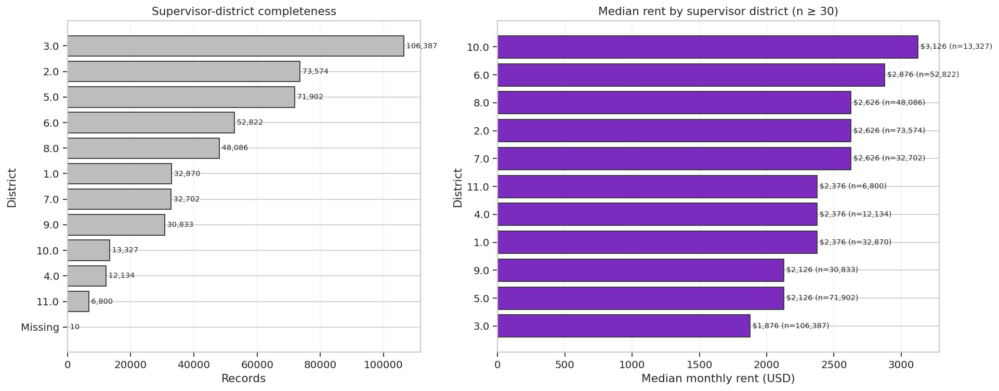

                     record_count  median_rent
supervisor_district                           
3.0                        106387       1875.5
5.0                         71902       2125.5
9.0                         30833       2125.5
1.0                         32870       2375.5
4.0                         12134       2375.5
11.0                         6800       2375.5
7.0                         32702       2625.5
2.0                         73574       2625.5
8.0                         48086       2625.5
6.0                         52822       2875.5
10.0                        13327       3125.5

In [142]:
district_col = "supervisor_district"
if district_col not in eda.columns:
    print("Supervisor-district analysis skipped: column is not present.")
else:
    district = eda[[district_col, target]].copy()
    district[district_col] = district[district_col].astype("string").fillna("Missing")
    district_counts = district[district_col].value_counts(dropna=False).sort_values()
    district_summary = district[district[district_col] != "Missing"].groupby(district_col)[target].agg(record_count="count", median_rent="median").query("record_count >= 30").sort_values("median_rent")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.25]})
    axes[0].barh(district_counts.index, district_counts.values, color="#BDBDBD", edgecolor="#333333")
    axes[0].set_title("Supervisor-district completeness"); axes[0].set_xlabel("Records"); axes[0].set_ylabel("District"); axes[0].grid(axis="x", alpha=.25)
    for y, value in enumerate(district_counts.values): axes[0].text(value, y, f" {value:,}", va="center", fontsize=8)
    if district_summary.empty:
        axes[1].text(.5, .5, "No district has enough records", ha="center", va="center"); axes[1].set_axis_off()
    else:
        axes[1].barh(district_summary.index.astype(str), district_summary["median_rent"], color="#7B2CBF", edgecolor="#333333")
        axes[1].set_title("Median rent by supervisor district (n ≥ 30)"); axes[1].set_xlabel("Median monthly rent (USD)"); axes[1].set_ylabel("District"); axes[1].grid(axis="x", alpha=.25)
        for y, (_, row) in enumerate(district_summary.iterrows()): axes[1].text(row["median_rent"], y, f" ${row['median_rent']:,.0f} (n={int(row['record_count']):,})", va="center", fontsize=8)
    plt.tight_layout(); plt.show()
    display(district_summary)
    print("Missing supervisor district percentage:", round((district[district_col] == "Missing").mean()*100, 2), "%")


## EDA interpretation and insights

Run the following cell after the EDA figures to print concise findings for the presentation.


In [144]:
# Evidence-based findings generated from the tables and plots above.
largest_bedroom = bedroom_counts.idxmax(); largest_bedroom_count = int(bedroom_counts.max())
highest_bedroom_group = bedroom_rent_summary["median_rent"].idxmax(); highest_bedroom_median = bedroom_rent_summary["median_rent"].max()
rent_sqft_corr = scatter_data.corr().iloc[0, 1] if len(scatter_data) > 1 else np.nan
print(f"1. Rent shape: mean=${plot_rent.mean():,.0f}, median=${plot_rent.median():,.0f}, skewness={plot_rent.skew():.2f}; the histogram plus full-range boxplot support the shape claim.")
print(f"2. The most common bedroom category is {largest_bedroom} ({largest_bedroom_count:,} records), supported by the composition bar chart.")
print(f"3. The highest bedroom-group median is {highest_bedroom_group}: ${highest_bedroom_median:,.0f}; compare both medians and record counts before presenting it as a stable difference.")
print(f"4. Rent–size Pearson correlation is {rent_sqft_corr:.2f}; the scatterplot shows the remaining spread, so this is association rather than a deterministic rule.")
print("5. Neighborhood, occupancy, utility, district, year/date, and coordinate plots should be interpreted with sample size and missingness visible in the supporting tables.")
print("6. The bedroom/bathroom grouped bars compare medians; the accompanying count table identifies sparse combinations.")


1. Rent shape: mean=$2,540, median=$2,376, skewness=0.85; the histogram plus full-range boxplot support the shape claim.
2. The most common bedroom category is One-Bedroom (196,571 records), supported by the composition bar chart.
3. The highest bedroom-group median is 5+: $6,376; compare both medians and record counts before presenting it as a stable difference.
4. Rent–size Pearson correlation is 0.63; the scatterplot shows the remaining spread, so this is association rather than a deterministic rule.
5. Neighborhood, occupancy, utility, district, year/date, and coordinate plots should be interpreted with sample size and missingness visible in the supporting tables.
6. The bedroom/bathroom grouped bars compare medians; the accompanying count table identifies sparse combinations.


## Submission-type analysis

**Question:** How are records distributed across submission types, and does typical rent differ between groups?

The count plot shows how much evidence each submission type contributes. The median-rent plot compares typical rent while displaying the record count. A difference in medians is descriptive association only; submission type may reflect reporting or administrative processes rather than a housing characteristic. Very small groups should not support strong conclusions.


In [146]:
if "submission_type" not in eda.columns:
    print("Submission-type analysis skipped: submission_type is not present in the cleaned dataset.")
else:
    submission_plot = eda.copy()
    submission_plot["submission_type"] = submission_plot["submission_type"].astype("string").fillna("Missing")
    submission_summary = (
        submission_plot.groupby("submission_type", dropna=False)[target]
        .agg(record_count="count", median_rent="median", mean_rent="mean")
        .sort_values("record_count", ascending=False)
    )
    display(submission_summary)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.15, 1]})
    sns.barplot(x=submission_summary["record_count"], y=submission_summary.index, color="#7B2CBF", ax=axes[0])
    axes[0].set(title="Records by submission type", xlabel="Number of records", ylabel="Submission type")
    axes[0].yaxis.label.set_rotation(0); axes[0].yaxis.labelpad = 55
    axes[0].grid(axis="x", alpha=.25)
    median_order = submission_summary.sort_values("median_rent").index
    sns.barplot(x=submission_summary.loc[median_order, "median_rent"], y=median_order, color="#E69F00", ax=axes[1])
    axes[1].set(title="Median rent by submission type", xlabel="Median monthly rent midpoint (USD)", ylabel="Submission type")
    axes[1].yaxis.label.set_rotation(0); axes[1].yaxis.labelpad = 55
    axes[1].grid(axis="x", alpha=.25)
    fig.suptitle("Submission type: evidence volume and typical rent")
    plt.tight_layout(); plt.show()
    print("Interpretation: use the left panel to judge sample-size support before comparing medians in the right panel.")


Submission-type analysis skipped: submission_type is not present in the cleaned dataset.


## Multivariate heatmaps — numeric relationships and joint rent structure

**Question:** How do several housing characteristics relate to rent at the same time, and which bedroom–bathroom combinations have enough evidence?

The correlation heatmap uses Spearman correlation because rent is skewed and contains outliers. Bedroom and bathroom categories are mapped to numeric equivalents only for this association summary. The joint rent heatmap masks combinations with fewer than 30 records; the adjacent count heatmap shows the evidence available for every combination.


                Monthly rent  Square footage  Property age  Bedrooms  Bathrooms
Monthly rent            1.00            0.59         -0.23      0.55       0.44
Square footage          0.59            1.00         -0.16      0.79       0.54
Property age           -0.23           -0.16          1.00     -0.07      -0.19
Bedrooms                0.55            0.79         -0.07      1.00       0.54
Bathrooms               0.44            0.54         -0.19      0.54       1.00

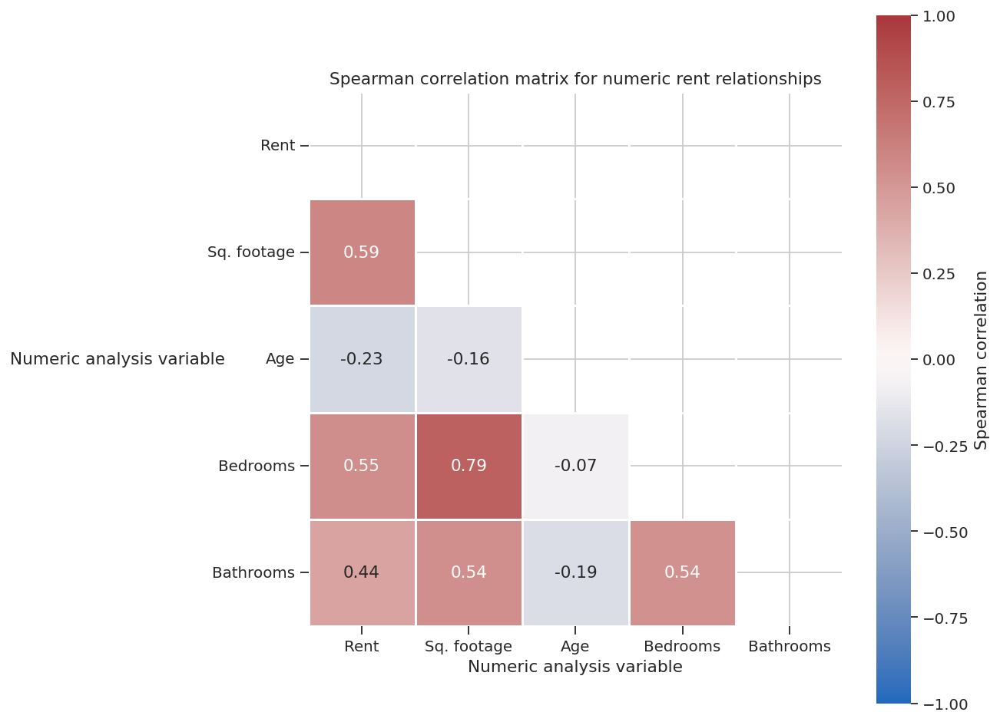

In [148]:
# Spearman correlation matrix for numeric analysis variables.
numeric_for_heatmap = pd.DataFrame(index=eda.index)
numeric_for_heatmap["Monthly rent"] = pd.to_numeric(eda[target], errors="coerce")
if "square_footage_midpoint" in eda.columns:
    numeric_for_heatmap["Square footage"] = pd.to_numeric(eda["square_footage_midpoint"], errors="coerce")
if "property_age" in eda.columns:
    numeric_for_heatmap["Property age"] = pd.to_numeric(eda["property_age"], errors="coerce")
if "bedroom_count" in eda.columns:
    numeric_for_heatmap["Bedrooms"] = eda["bedroom_count"].map({"0": 0, "Studio": 0, "One-Bedroom": 1, "Two-Bedroom": 2, "Three-Bedroom": 3, "Four-Bedroom": 4, "5+": 5})
if "bathroom_count" in eda.columns:
    numeric_for_heatmap["Bathrooms"] = eda["bathroom_count"].map({"1": 1.0, "1.5": 1.5, "2": 2.0, "2.5": 2.5, "3+": 3.0})
numeric_for_heatmap = numeric_for_heatmap.apply(pd.to_numeric, errors="coerce")
spearman_corr = numeric_for_heatmap.corr(method="spearman", min_periods=2)
display(spearman_corr.round(2))

mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.7,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Spearman correlation"},
    ax=ax,
)
ax.set_title("Spearman correlation matrix for numeric rent relationships")
ax.set_xlabel("Numeric analysis variable")
ax.set_ylabel("Numeric analysis variable", rotation=0, labelpad=65, va="center")
heatmap_labels = ["Rent", "Sq. footage", "Age", "Bedrooms", "Bathrooms"]
ax.set_xticklabels(heatmap_labels, rotation=0, ha="center")
ax.set_yticklabels(heatmap_labels, rotation=0, va="center")
ax.tick_params(axis="both", which="major", length=6, width=1)
plt.tight_layout(); plt.show()


Median-rent cells with fewer than 30 records are masked; the count heatmap keeps those cells visible for review.


                    1     1.5       2     2.5      3+
Studio         1626.0  3126.0  3126.0    <NA>  3126.0
One-Bedroom    2376.0  3376.0  3626.0  3750.0  3876.0
Two-Bedroom    2876.0  3376.0  3876.0  4626.0  5376.0
Three-Bedroom  3376.0  3876.0  4376.0  5376.0  5876.0
Four-Bedroom   3876.0  4126.0  4876.0  6126.0  6126.0
5+             4250.0  4500.0  5876.0  6500.0  6876.0

                    1   1.5      2   2.5    3+
Studio         115585    54    113  <NA>    36
One-Bedroom    191076  1815   1288    32     4
Two-Bedroom     74113  5001  39135  1231   205
Three-Bedroom    8973  2693  12879  1664  1767
Four-Bedroom      924   575   2529   450  1246
5+                102    60    346    88   746

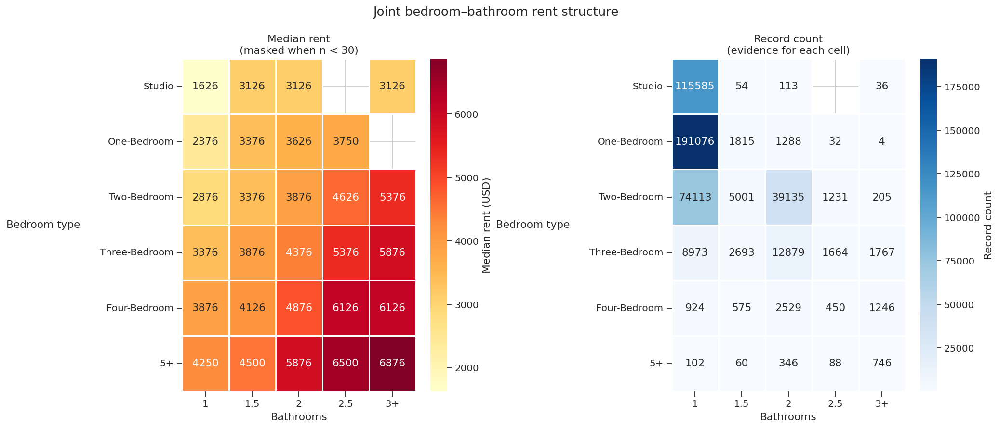

In [149]:
# Joint bedroom-bathroom heatmaps: median rent and record counts.
combo_heatmap = pd.DataFrame({
    "Bedrooms": eda["bedroom_count"].map({"0": 0, "Studio": 0, "One-Bedroom": 1, "Two-Bedroom": 2, "Three-Bedroom": 3, "Four-Bedroom": 4, "5+": 5}),
    "Bathrooms": eda["bathroom_count"].map({"1": 1.0, "1.5": 1.5, "2": 2.0, "2.5": 2.5, "3+": 3.0}),
    "Rent": eda[target],
}).dropna()
bedroom_levels = [0, 1, 2, 3, 4, 5]
bathroom_levels = [1.0, 1.5, 2.0, 2.5, 3.0]
rent_matrix = combo_heatmap.pivot_table(index="Bedrooms", columns="Bathrooms", values="Rent", aggfunc="median").reindex(index=bedroom_levels, columns=bathroom_levels)
count_matrix = combo_heatmap.pivot_table(index="Bedrooms", columns="Bathrooms", values="Rent", aggfunc="count").reindex(index=bedroom_levels, columns=bathroom_levels)
rent_matrix.index = ["Studio", "One-Bedroom", "Two-Bedroom", "Three-Bedroom", "Four-Bedroom", "5+"]
count_matrix.index = rent_matrix.index
rent_matrix.columns = ["1", "1.5", "2", "2.5", "3+"]
count_matrix.columns = rent_matrix.columns
minimum_records = 30
sparse_or_missing = rent_matrix.isna() | (count_matrix < minimum_records)
display(rent_matrix.round(0))
display(count_matrix.astype("Int64"))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1, 1]})
sns.heatmap(
    rent_matrix.astype(float),
    mask=sparse_or_missing,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Median rent (USD)"},
    ax=axes[0],
)
axes[0].set_title("Median rent\n(masked when n < 30)")
axes[0].set_xlabel("Bathrooms")
axes[0].set_ylabel("Bedroom type", rotation=0, labelpad=65, va="center")
sns.heatmap(
    count_matrix.astype(float),
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Record count"},
    ax=axes[1],
)
axes[1].set_title("Record count\n(evidence for each cell)")
axes[1].set_xlabel("Bathrooms")
axes[1].set_ylabel("Bedroom type", rotation=0, labelpad=65, va="center")
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")
    ax.tick_params(axis="both", which="major", length=6, width=1)
fig.suptitle("Joint bedroom–bathroom rent structure")
plt.tight_layout(); plt.show()
print(f"Median-rent cells with fewer than {minimum_records} records are masked; the count heatmap keeps those cells visible for review.")


## EDA decision table

This table records the decisions needed before modeling. The exact numeric results are generated when the notebook is run on the source CSV.


In [151]:
decision_table = pd.DataFrame([
    [target, "numeric target", "drop rows with missing values", "The lecture states that a target should not be imputed because it invents answers"],
    ["monthly_rent_midpoint <= 0", "invalid/non-market rent for this analysis", "exclude from all rent visualizations and predictor comparisons; report separately", "The rent analysis is defined for positive monthly rent; zero-rent records are retained only for audit"],
    ["monthly_rent", "raw range/text field", "retain for audit; analyze midpoint", "Ranges and open-ended values require an explicit numeric rule"],
    ["bedroom_count / bathroom_count", "categorical", "standardize labels; retain missing for EDA; add Missing category plus indicator for modeling", "Category labels were inconsistent and missingness may carry information"],
    ["square_footage_midpoint / property_age", "numeric features", "validate first; median-impute only after EDA, with missingness indicators", "The lecture recommends median when skew/outliers make the mean unstable"],
    ["supervisor_district", "numeric/categorical geographic feature", "report missingness; retain Missing/indicator for modeling; compare districts with n rule", "Missing geography should not be silently assigned to a real district"],
    ["occupancy_or_vacancy_date", "date feature", "parse and validate; do not blindly impute; derive year/month only from valid dates", "Dates have domain validity rules and missing dates may be informative"],
    ["analysis_neighborhood / street_name / submission_type", "categorical features", "compare groups with adequate n; Missing category plus indicator for modeling", "Rare groups make summaries unstable and missingness can carry information"],
    ["utility and past_occupancy fields", "binary/categorical predictors", "validate coding; retain missing indicators for modeling", "Utility/rent differences are descriptive and may be confounded by composition"],
], columns=["Variable", "Role", "Decision", "Reason"])
display(decision_table)


                                                Variable                                       Role                                                                                      Decision                                                                                                 Reason
0                                  monthly_rent_midpoint                             numeric target                                                                 drop rows with missing values                      The lecture states that a target should not be imputed because it invents answers
1                             monthly_rent_midpoint <= 0  invalid/non-market rent for this analysis             exclude from all rent visualizations and predictor comparisons; report separately  The rent analysis is defined for positive monthly rent; zero-rent records are retained only for audit
2                                           monthly_rent                       raw range/text field          

## Imputation plan for later modeling

The descriptive EDA uses observed values and complete cases for each chart. Imputation is kept separate so it does not change the distributions being described. The following optional model-ready copy uses median imputation for numeric features and an explicit `Missing` category for categorical features.


In [153]:
# Model-ready imputation happens only after EDA and the decision table.
# Missingness indicators preserve information about which values were originally absent.
model_ready = eda.copy()
numeric_impute_columns = [c for c in ["square_footage_midpoint", "property_age", "supervisor_district", "past_occupancy"] if c in model_ready.columns]
categorical_impute_columns = [c for c in ["bedroom_count", "bathroom_count", "analysis_neighborhood", "street_name", "submission_type"] if c in model_ready.columns]

for col in numeric_impute_columns:
    model_ready[f"{col}_missing"] = model_ready[col].isna().astype("int8")
    model_ready[col] = model_ready[col].fillna(model_ready[col].median())

for col in categorical_impute_columns:
    model_ready[f"{col}_missing"] = model_ready[col].isna().astype("int8")
    model_ready[col] = model_ready[col].astype("string").fillna("Missing")

print("Numeric columns imputed with medians:", numeric_impute_columns)
print("Categorical columns imputed with Missing:", categorical_impute_columns)
print("Missingness indicators added:", [c for c in model_ready.columns if c.endswith("_missing")])
display(model_ready[[c for c in model_ready.columns if c.endswith("_missing")]].mean().mul(100).round(2).to_frame("original_missing_percentage"))


Numeric columns imputed with medians: ['square_footage_midpoint', 'property_age', 'supervisor_district', 'past_occupancy']
Categorical columns imputed with Missing: ['bedroom_count', 'bathroom_count', 'analysis_neighborhood', 'street_name']
Missingness indicators added: ['square_footage_midpoint_missing', 'property_age_missing', 'supervisor_district_missing', 'past_occupancy_missing', 'bedroom_count_missing', 'bathroom_count_missing', 'analysis_neighborhood_missing', 'street_name_missing']


                                 original_missing_percentage
square_footage_midpoint_missing                         2.19
property_age_missing                                    2.91
supervisor_district_missing                             0.00
past_occupancy_missing                                 24.50
bedroom_count_missing                                   0.16
bathroom_count_missing                                  0.09
analysis_neighborhood_missing                           0.00
street_name_missing                                     0.01

## Data-handling transformations: before and after

These paired visuals make the two numeric transformations explicit. The left panels show the original categorical/range labels; the right panels show the numeric midpoint features used for rent analysis. Missing and zero-rent values remain visible for audit, while the later rent EDA uses positive rent only.


Rent midpoint values include zero-rent records for audit; positive-rent filtering is applied before rent EDA.


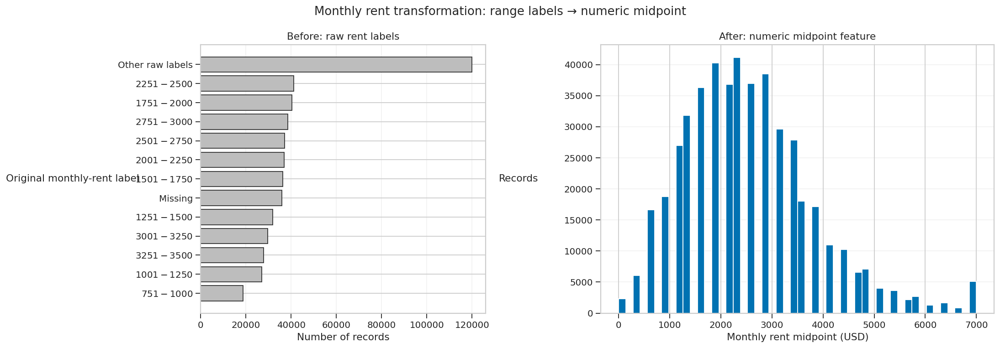

                           raw_rent_label  lower_bound  upper_bound  midpoint_used
428     $0 (no rent paid by the occupant)         <NA>         <NA>           <NA>
394                               $1-$250            1          250          125.5
5                             $1001-$1250         1001         1250         1125.5
7                             $1251-$1500         1251         1500         1375.5
0                             $1501-$1750         1501         1750         1625.5
9712                          $1750-$2000         1750         2000         1875.0
11                            $1751-$2000         1751         2000         1875.5
32                            $2001-$2250         2001         2250         2125.5
61                            $2251-$2500         2251         2500         2375.5
343844                          $250-$500          250          500          375.0
17                            $2501-$2750         2501         2750         2625.5
158 

In [155]:
# Before-and-after transformation: monthly rent ranges to numeric midpoint.
raw_rent_counts = cleaned["monthly_rent"].astype("string").str.strip().replace("", pd.NA).fillna("Missing").value_counts()
raw_rent_top = raw_rent_counts.nlargest(12).sort_values()
raw_rent_remainder = raw_rent_counts.drop(raw_rent_top.index).sum()
if raw_rent_remainder > 0:
    raw_rent_top["Other raw labels"] = raw_rent_remainder
raw_rent_top = raw_rent_top.sort_values()
rent_midpoints = pd.to_numeric(cleaned["monthly_rent_midpoint"], errors="coerce").dropna()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.05, 1.45]})
axes[0].barh(raw_rent_top.index, raw_rent_top.values, color="#BDBDBD", edgecolor="#333333")
axes[0].set_title("Before: raw rent labels")
axes[0].set_xlabel("Number of records")
axes[0].set_ylabel("Original monthly-rent label", rotation=0, labelpad=55, va="center")
axes[0].grid(axis="x", alpha=.25)
axes[1].hist(rent_midpoints, bins=50, color="#0072B2", edgecolor="white")
axes[1].set_title("After: numeric midpoint feature")
axes[1].set_xlabel("Monthly rent midpoint (USD)")
axes[1].set_ylabel("Records", rotation=0, labelpad=55, va="center")
axes[1].grid(axis="y", alpha=.25)
for ax in axes:
    ax.tick_params(axis="both", which="major", length=6, width=1)
fig.suptitle("Monthly rent transformation: range labels → numeric midpoint")
plt.tight_layout(); plt.show()

rent_examples = pd.DataFrame({
    "raw_rent_label": cleaned["monthly_rent"].astype("string"),
    "lower_bound": cleaned["rent_lower_bound"],
    "upper_bound": cleaned["rent_upper_bound"],
    "midpoint_used": cleaned["monthly_rent_midpoint"],
}).drop_duplicates().dropna(subset=["raw_rent_label"]).sort_values("raw_rent_label").head(15)
display(rent_examples)
print("Rent midpoint values include zero-rent records for audit; positive-rent filtering is applied before rent EDA.")


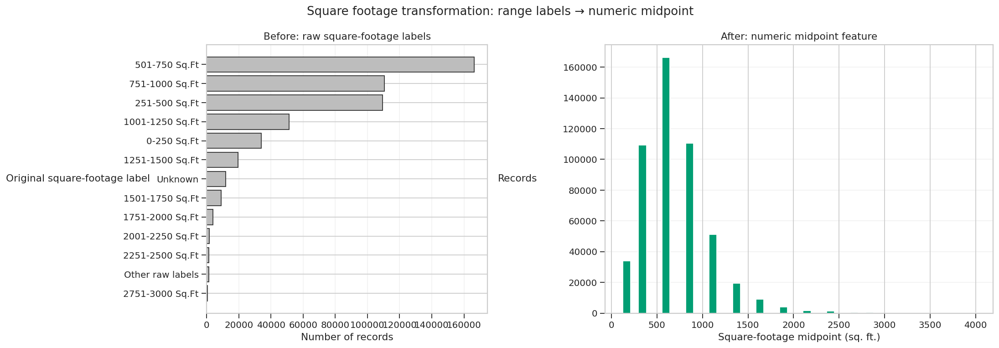

     raw_square_footage_label  midpoint_used
37                0-250 Sq.Ft          125.0
2             1001-1250 Sq.Ft         1125.5
8             1251-1500 Sq.Ft         1375.5
28            1501-1750 Sq.Ft         1625.5
38            1751-2000 Sq.Ft         1875.5
352           2001-2250 Sq.Ft         2125.5
363           2251-2500 Sq.Ft         2375.5
894           2501-2750 Sq.Ft         2625.5
5               251-500 Sq.Ft          375.5
1205          2751-3000 Sq.Ft         2875.5
2367          3001-3250 Sq.Ft         3125.5
152           3251-3500 Sq.Ft         3375.5
2667          3501-3750 Sq.Ft         3625.5
954           3751-4000 Sq.Ft         3875.5
2331              4000+ Sq.Ft         4000.0

In [156]:
# Before-and-after transformation: square-footage ranges to numeric midpoint.
raw_sqft_counts = cleaned["square_footage"].astype("string").str.strip().replace("", pd.NA).fillna("Missing").value_counts()
raw_sqft_top = raw_sqft_counts.nlargest(12).sort_values()
raw_sqft_remainder = raw_sqft_counts.drop(raw_sqft_top.index).sum()
if raw_sqft_remainder > 0:
    raw_sqft_top["Other raw labels"] = raw_sqft_remainder
raw_sqft_top = raw_sqft_top.sort_values()
sqft_midpoints = pd.to_numeric(cleaned["square_footage_midpoint"], errors="coerce").dropna()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.05, 1.45]})
axes[0].barh(raw_sqft_top.index, raw_sqft_top.values, color="#BDBDBD", edgecolor="#333333")
axes[0].set_title("Before: raw square-footage labels")
axes[0].set_xlabel("Number of records")
axes[0].set_ylabel("Original square-footage label", rotation=0, labelpad=55, va="center")
axes[0].grid(axis="x", alpha=.25)
axes[1].hist(sqft_midpoints, bins=45, color="#009E73", edgecolor="white")
axes[1].set_title("After: numeric midpoint feature")
axes[1].set_xlabel("Square-footage midpoint (sq. ft.)")
axes[1].set_ylabel("Records", rotation=0, labelpad=55, va="center")
axes[1].grid(axis="y", alpha=.25)
for ax in axes:
    ax.tick_params(axis="both", which="major", length=6, width=1)
fig.suptitle("Square footage transformation: range labels → numeric midpoint")
plt.tight_layout(); plt.show()

sqft_examples = pd.DataFrame({
    "raw_square_footage_label": cleaned["square_footage"].astype("string"),
    "midpoint_used": cleaned["square_footage_midpoint"],
}).drop_duplicates().dropna(subset=["raw_square_footage_label"]).sort_values("raw_square_footage_label").head(15)
display(sqft_examples)


         variable   representation  skewness  records
0    Monthly rent      lower bound      0.67   477394
1    Monthly rent         midpoint      0.67   477394
2    Monthly rent      upper bound      0.67   477394
3  Square footage      lower bound      1.89   474788
4  Square footage         midpoint      1.89   474788
5  Square footage      upper bound      1.89   474788
6    Monthly rent  entire positive      0.85   481447
7  Square footage     entire valid      1.63   470893

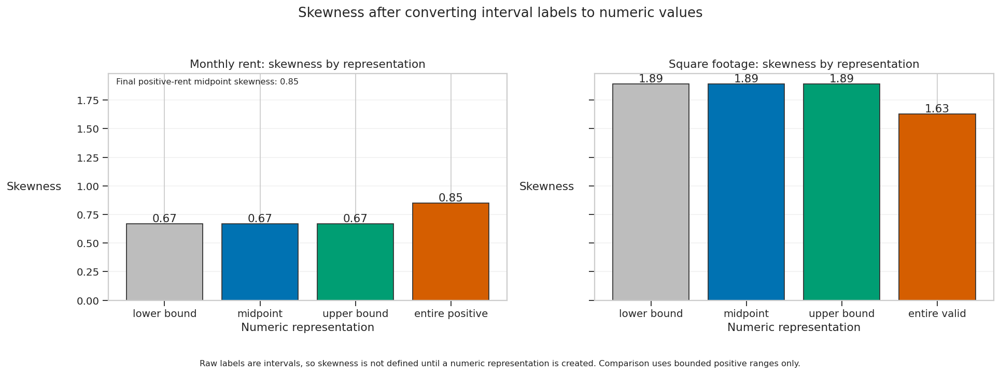

In [157]:
# Explicit skewness comparison for the transformed numeric variables.
# Raw interval labels themselves do not have a numeric skewness. For a fair transformation check,
# compare lower bound, midpoint, and upper bound on the same bounded, positive ranges.
rent_bounded = pd.DataFrame({
    "lower bound": pd.to_numeric(cleaned["rent_lower_bound"], errors="coerce"),
    "midpoint": pd.to_numeric(cleaned["monthly_rent_midpoint"], errors="coerce"),
    "upper bound": pd.to_numeric(cleaned["rent_upper_bound"], errors="coerce"),
}).dropna()
rent_bounded = rent_bounded[(rent_bounded > 0).all(axis=1)]

sqft_text = cleaned["square_footage"].astype("string").str.strip().str.lower().str.replace(",", "", regex=False)
sqft_parts = sqft_text.str.extract(r"^(\d+(?:\.\d+)?)\s*[-–]\s*(\d+(?:\.\d+)?)", expand=True)
sqft_bounded = pd.DataFrame({
    "lower bound": pd.to_numeric(sqft_parts[0], errors="coerce"),
    "upper bound": pd.to_numeric(sqft_parts[1], errors="coerce"),
})
sqft_bounded["midpoint"] = (sqft_bounded["lower bound"] + sqft_bounded["upper bound"]) / 2
sqft_bounded = sqft_bounded.dropna()
sqft_bounded = sqft_bounded[(sqft_bounded > 0).all(axis=1)][["lower bound", "midpoint", "upper bound"]]

skew_rows = []
for variable, frame in [("Monthly rent", rent_bounded), ("Square footage", sqft_bounded)]:
    for representation in ["lower bound", "midpoint", "upper bound"]:
        skew_rows.append({
            "variable": variable,
            "representation": representation,
            "skewness": frame[representation].skew(),
            "records": len(frame),
        })
if "eda" in globals() and target in eda.columns:
    skew_rows.append({
        "variable": "Monthly rent",
        "representation": "entire positive",
        "skewness": pd.to_numeric(eda[target], errors="coerce").dropna().skew(),
        "records": int(pd.to_numeric(eda[target], errors="coerce").notna().sum()),
    })
if "eda" in globals() and "square_footage_midpoint" in eda.columns:
    sqft_all = pd.to_numeric(eda["square_footage_midpoint"], errors="coerce").dropna()
    skew_rows.append({
        "variable": "Square footage",
        "representation": "entire valid",
        "skewness": sqft_all.skew(),
        "records": int(sqft_all.shape[0]),
    })
skew_comparison = pd.DataFrame(skew_rows)
display(skew_comparison.round({"skewness": 2}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, variable in zip(axes, ["Monthly rent", "Square footage"]):
    temp = skew_comparison[skew_comparison["variable"] == variable]
    bar_colors = ["#BDBDBD", "#0072B2", "#009E73", "#D55E00"]
    bars = ax.bar(temp["representation"], temp["skewness"], color=bar_colors[:len(temp)], edgecolor="#333333")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{variable}: skewness by representation")
    ax.set_xlabel("Numeric representation")
    ax.set_ylabel("Skewness", rotation=0, labelpad=45, va="center")
    ax.grid(axis="y", alpha=.25)
    ax.tick_params(axis="both", which="major", length=6, width=1)
    ax.tick_params(axis="x", labelrotation=0)
    for bar, value in zip(bars, temp["skewness"]):
        ax.text(bar.get_x() + bar.get_width()/2, value, f"{value:.2f}", ha="center", va="bottom" if value >= 0 else "top")
axes[0].text(0.02, 0.98, f"Final positive-rent midpoint skewness: {eda[target].skew():.2f}", transform=axes[0].transAxes, va="top", fontsize=9)
fig.suptitle("Skewness after converting interval labels to numeric values")
fig.text(0.5, 0.01, "Raw labels are intervals, so skewness is not defined until a numeric representation is created. Comparison uses bounded positive ranges only.", ha="center", fontsize=9)
plt.tight_layout(rect=[0, 0.06, 1, 0.94]); plt.show()


## Numeric shape and skewness diagnostics

Following the lecture sequence, each continuous numeric variable is inspected in its original analysis scale using a histogram, mean–median comparison, skewness value, and QQ plot. These are descriptive EDA diagnostics; no predictor transformation or outlier removal is applied here.


Decision: preserve the original analysis scales for EDA. Use median/IQR for skewed summaries; do not automatically transform or remove square footage or property age.


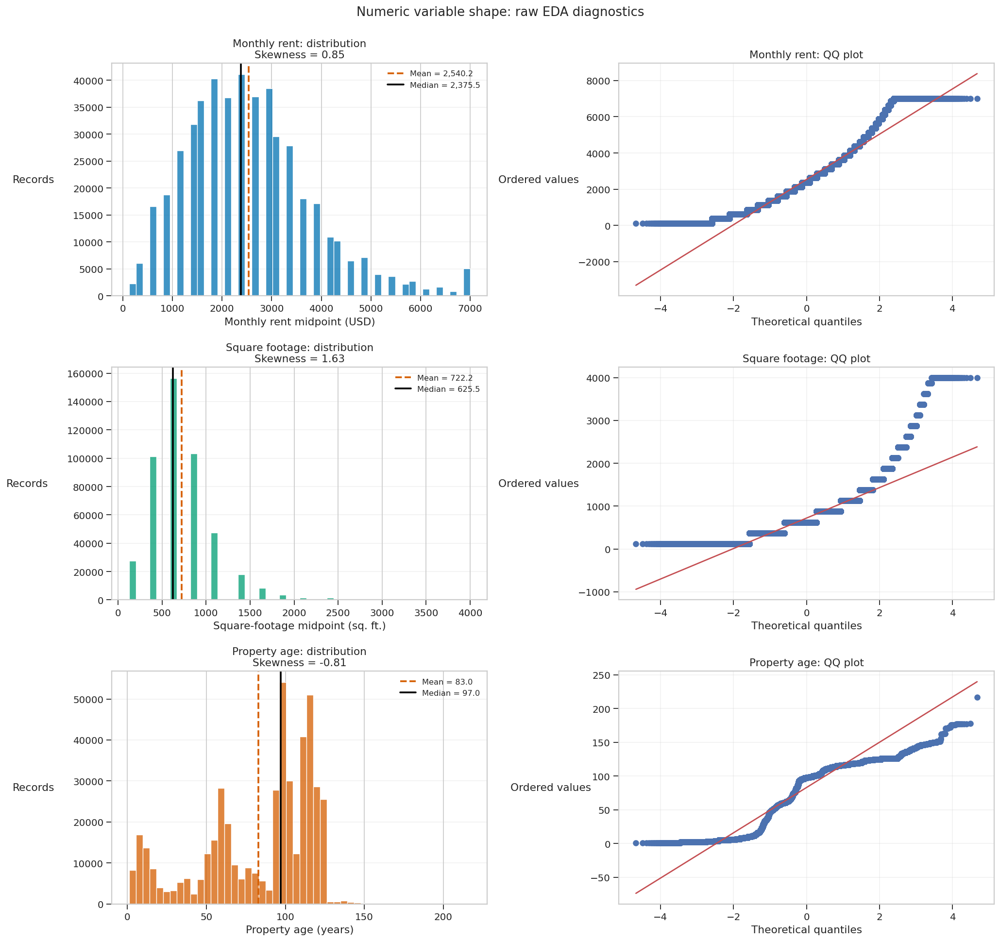

         variable  records     mean  median  skewness interpretation
0    Monthly rent   481447  2540.20  2375.5      0.85   Right-skewed
1  Square footage   470893   722.23   625.5      1.63   Right-skewed
2    Property age   467433    83.02    97.0     -0.81    Left-skewed

In [159]:
# Inspect shape and skewness without transforming the numeric variables.
from scipy import stats

numeric_shape_specs = [
    ("Monthly rent", target, "Monthly rent midpoint (USD)"),
    ("Square footage", "square_footage_midpoint", "Square-footage midpoint (sq. ft.)"),
    ("Property age", "property_age", "Property age (years)"),
]
numeric_shape_rows = []
fig, axes = plt.subplots(len(numeric_shape_specs), 2, figsize=(16, 15))
for row, (label, column, xlabel) in enumerate(numeric_shape_specs):
    values = pd.to_numeric(eda[column], errors="coerce").dropna()
    if label == "Monthly rent":
        values = values[values > 0]
    mean_value = values.mean()
    median_value = values.median()
    skew_value = values.skew()
    numeric_shape_rows.append({
        "variable": label,
        "records": len(values),
        "mean": mean_value,
        "median": median_value,
        "skewness": skew_value,
        "interpretation": "Right-skewed" if skew_value > 0.5 else ("Left-skewed" if skew_value < -0.5 else "Approximately symmetric"),
    })

    hist_ax = axes[row, 0]
    sns.histplot(values, bins=50, color=["#0072B2", "#009E73", "#D55E00"][row], ax=hist_ax)
    hist_ax.axvline(mean_value, color="#D55E00", linestyle="--", linewidth=2, label=f"Mean = {mean_value:,.1f}")
    hist_ax.axvline(median_value, color="#000000", linestyle="-", linewidth=2, label=f"Median = {median_value:,.1f}")
    hist_ax.set_title(f"{label}: distribution\nSkewness = {skew_value:.2f}")
    hist_ax.set_xlabel(xlabel)
    hist_ax.set_ylabel("Records", rotation=0, labelpad=45, va="center")
    hist_ax.legend(frameon=False, fontsize=9)
    hist_ax.grid(axis="y", alpha=.25)

    qq_ax = axes[row, 1]
    stats.probplot(values, dist="norm", plot=qq_ax)
    qq_ax.set_title(f"{label}: QQ plot")
    qq_ax.set_xlabel("Theoretical quantiles")
    qq_ax.set_ylabel("Ordered values", rotation=0, labelpad=45, va="center")
    qq_ax.grid(alpha=.25)

for ax in axes.flat:
    ax.tick_params(axis="both", which="major", length=6, width=1)
fig.suptitle("Numeric variable shape: raw EDA diagnostics", y=0.995)
plt.tight_layout(); plt.show()
numeric_shape_summary = pd.DataFrame(numeric_shape_rows)
display(numeric_shape_summary.round({"mean": 2, "median": 2, "skewness": 2}))
print("Decision: preserve the original analysis scales for EDA. Use median/IQR for skewed summaries; do not automatically transform or remove square footage or property age.")


## Questions for the presentation

Use these questions as slide titles or speaking prompts. Each question is answered by one or more visualizations above.

1. What does the rent distribution look like, and why is the median more representative than the mean?
2. How did bedroom and bathroom standardization change the usable categories and record counts?
3. How strongly does rent differ across bedroom categories when both median rent and sample size are considered?
4. Do larger units generally have higher rent, and how much variation remains at the same size?
5. How do bedroom and bathroom counts jointly relate to rent, and which combinations are too sparse for strong conclusions?
6. Which neighborhoods have the highest typical rent after applying a minimum record-count rule?
7. Does the rent–size relationship look different for occupied and vacant records?
8. Are rent differences across utility-inclusion statuses large enough to matter, or could they reflect composition differences?
9. How do property age, supervisor district, past occupancy, and coordinates add context to rent differences?
10. Which variables have the most missingness, and how does that affect descriptive analysis versus later modeling?
11. Which findings are associations only, and what prevents us from claiming causation?
12. What cleaning and imputation decisions should be carried into the next modeling step?


In [161]:
# Presentation evidence summary: run this cell after all EDA and imputation cells.
evidence_rows = []
if "plot_rent" in globals():
    evidence_rows.append(["Rent shape", f"Median ${plot_rent.median():,.0f}; mean ${plot_rent.mean():,.0f}; skewness {plot_rent.skew():.2f}", "Full-range histogram, central 99% view, and outlier boxplot"])
if "zero_rent_audit" in globals():
    positive_used = int(zero_rent_audit.loc[zero_rent_audit["group"] == "Positive rent used for EDA", "records"].iloc[0])
    excluded_nonpositive = int(zero_rent_audit.loc[zero_rent_audit["group"] == "Zero/non-positive rent", "records"].iloc[0])
    evidence_rows.append(["Rent validity", f"{positive_used:,} positive-rent records used; {excluded_nonpositive:,} zero/nonpositive records reported separately", "Zero-rent audit"])
if "bedroom_rent_summary" in globals():
    top_bedroom = bedroom_rent_summary["median_rent"].idxmax()
    evidence_rows.append(["Bedrooms", f"Highest displayed median: {top_bedroom}", "Rent by bedroom boxplot and summary table"])
if "year_summary" in globals() and not year_summary.empty:
    evidence_rows.append(["Submission year", f"{int(year_summary['submission_year'].min())}–{int(year_summary['submission_year'].max())}", "Overall and occupancy-stratified rent trend"])
if "decision_table" in globals():
    evidence_rows.append(["Imputation order", "EDA and decision table completed before model-ready imputation", "Decision table and imputation section"])
presentation_evidence = pd.DataFrame(evidence_rows, columns=["Question area", "Observed result", "Supporting output"])
display(presentation_evidence)


      Question area                                                                     Observed result                                            Supporting output
0        Rent shape                                           Median $2,376; mean $2,540; skewness 0.85  Full-range histogram, central 99% view, and outlier boxplot
1     Rent validity  481,447 positive-rent records used; 6 zero/nonpositive records reported separately                                              Zero-rent audit
2          Bedrooms                                                        Highest displayed median: 5+                    Rent by bedroom boxplot and summary table
3   Submission year                                                                           2022–2026                  Overall and occupancy-stratified rent trend
4  Imputation order                      EDA and decision table completed before model-ready imputation                        Decision table and imputation section